<a href="https://colab.research.google.com/github/vig202204/A-B-Test_Python_BigQuery_Tableau/blob/main/Portfolio_Project_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Мета цього завдання
>💡  У цьому портфоліо проекті побудовано аналітику продажів інтернет-магазину, використовуючи три інструменти: `SQL`, `Python` та `Tableau`.

`Мета проекту:`
- показати навички вивантаження даних із бази даних за допомогою `SQL`;
- показати навички `розвідувального` та `статистичного` аналізу у `Python`;
- показати навички побудови дашбордів у `Tableau`.


## У цьому портфоліо проекті:

У цьому портфоліо проекті побудувати аналітику продажів інтернет-магазину, використовуючи три інструменти: SQL, Python та Tableau.

**Мета проекту:**
- показати навички вивантаження даних із бази даних за допомогою `SQL`;
- показати навички розвідувального та статистичного аналізу у `Python`;
- показати навички побудови дашбордів у `Tableau`.

**Вигляд отриманих результатів:**
- `Jupyter notebook` із завантаженням даних з бази, розвідувальним та статистичним аналізом у Python;
- Дашборд у `Tableau Public`.


**Етапи проєкту:**

1. **Data overview**. Розуміння даних та їх змісту.
    - За допомогою скрипта Python підключитись до бази даних в Google BigQuery (DA dataset).
    - Виявити ключові поля, що поєднують таблиці.
2. **Data cleaning**. Робота із пропущеними даними, некоректними даними, аномаліями.
    - Подивись, чи є пропущені значення у кожній таблиці, оціни їх долю, спробуй зрозуміти причини їх виникнення.
    - Заповни або видали пропущені значення, обґрунтувавши свою думку.
  - Подивись, чи всі типи даних розпізнаються коректно. Якщо є розбіжності, потрібно виявити та усунути причини, за потреби, зробити перетворення типів у колонках.
  - Дослідити дані на наявність аномалій.
3. **Data analysis and visualization**.
На основі таблиць, наявних у базі даних, напиши запит у Python щоб створити датасет, який містить такі поля:
- дата замовлення;
- ідентифікатор сесії;
- континент;
- країна;
- девайс;
- браузер;
- назва моделі пристрою;
- операційна система;
- мова браузера;
- інформація про джерело трафіку;
- канал трафіку;
- ідентифікатор зареєстрованого;
- користувача;
- чи підтвердив користувач свій email;
- чи підписався користувач на розсилку;
- категорія товару;
- назва товару;
- ціна;
- короткий опис товару.



##  -ETL-


### Виконуємо імпорт необхідних бібліотек для виконання подальших кроків цього завдання:

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import calendar

# Connaction to sources
from google.colab import auth
from google.cloud import bigquery
from google.colab import drive

### Під'єднаємось до джерела даних

In [154]:
# Singn In to DB
auth.authenticate_user()

client = bigquery.Client(project="data-analytics-mate")


### Імпортуємо ісходні дані

#### З огляду на бізнес-вимоги
зробимо огляд наступних таблиць:
1. Для проведення аналітичних досліджень планується використовувати дані з наступних таблиць системи автоматизації інтернет-магазину, а саме:
- `data-analytics-mate.DA.session`
- `data-analytics-mate.DA.account`
- `data-analytics-mate.DA.order`
- `data-analytics-mate.DA.product`
- `data-analytics-mate.DA.account_session`
- `data-analytics-mate.DA.session_params`


2. З огляду на помірний розмір таблиць з даними зробимо `Data Owerview` без використання обмеження `LIMIT 1000`.

```
Size of the table session:         699090
Size of the table account:         183324
Size of the table order:           67076
Size of the table product:         14810
Size of the table account_session: 55890
Size of the table account_session: 3844995
```






In [155]:
# @title
# Count sessions
query_session = """
SELECT
  *
  # count(ga_session_id) AS session_cnt
FROM
  `data-analytics-mate.DA.session`
"""
df_session = client.query(query_session).result().to_dataframe()
print(f"Size of the table session: {df_session.size}")

# Count accounts
query_account = """
SELECT *
  # count(id) AS account_cnt
FROM
  `data-analytics-mate.DA.account`
"""
df_account = client.query(query_account).result().to_dataframe()
print(f"\nSize of the table account: {df_account.size}")

# Count orders
query_order = """
SELECT *
  # count(item_id) AS item_id_cnt
FROM
  `data-analytics-mate.DA.order`
"""
df_order = client.query(query_order).result().to_dataframe()
print(f"\nSize of the table order: {df_order.size}")

# Count product
query_product = """
SELECT *
  # count(item_id) AS item_id_cnt
FROM
  `data-analytics-mate.DA.product`
"""
df_product = client.query(query_product).result().to_dataframe()
print(f"\nSize of the table product: {df_product.size}")

# Count account_session
query_account_session = """
SELECT *
  # count(ga_session_id) AS ga_session_id_cnt
FROM
  `data-analytics-mate.DA.account_session`
"""
df_account_session = client.query(query_account_session).result().to_dataframe()
print(f"\nSize of the table account_session: {df_account_session.size}")

# Count sessions_params
query_session_params = """
SELECT *
  # count(ga_session_id) AS session_params_cnt
FROM
  `data-analytics-mate.DA.session_params`
"""
df_session_params = client.query(query_session_params).result().to_dataframe()
print(f"\nSize of the table account_session: {df_session_params.size}")

Size of the table session: 699090

Size of the table account: 183324

Size of the table order: 67076

Size of the table product: 14810

Size of the table account_session: 55890

Size of the table account_session: 3844995


#### 3. Додамо  параметри для подальшого використання під час проведення аналітичних досліджень планується.

##### 3.1 Приймемо для цього проекту корпоративну палітру кольорів:

In [156]:
# 3.1 Corporate ColorSet

# Define a custom color palette
custom_tableau_palette = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']
custom_tableau_palette_sns = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#bab0ac']
# Reserved colorSet
# custom_tableau_palette = ['#edc949', '#af7aa1', '#ff9da7', '#9c755f', '#bab0ac']


### Data overview.

#### Розуміння даних та їх змісту (розвідувальний аналіз).

> Discovery (Знайомство)

Розберемось зі змістом колонок, зробимо їх опис.
Виявимо ключові поля таблиць.

Повний (більш розгорнутий) розділ щодо знайомства з структурою тв наповнення даними поточного проекту винесено [у окремий документ `Portfolio_project_Data_Overview.ipynb`](https://colab.research.google.com/drive/1lyZI9tl6q7BZo0QmWuneQ85gf-PQidIx?usp=sharing).

Блок-схема таблиць та їх взаємозв'язків:
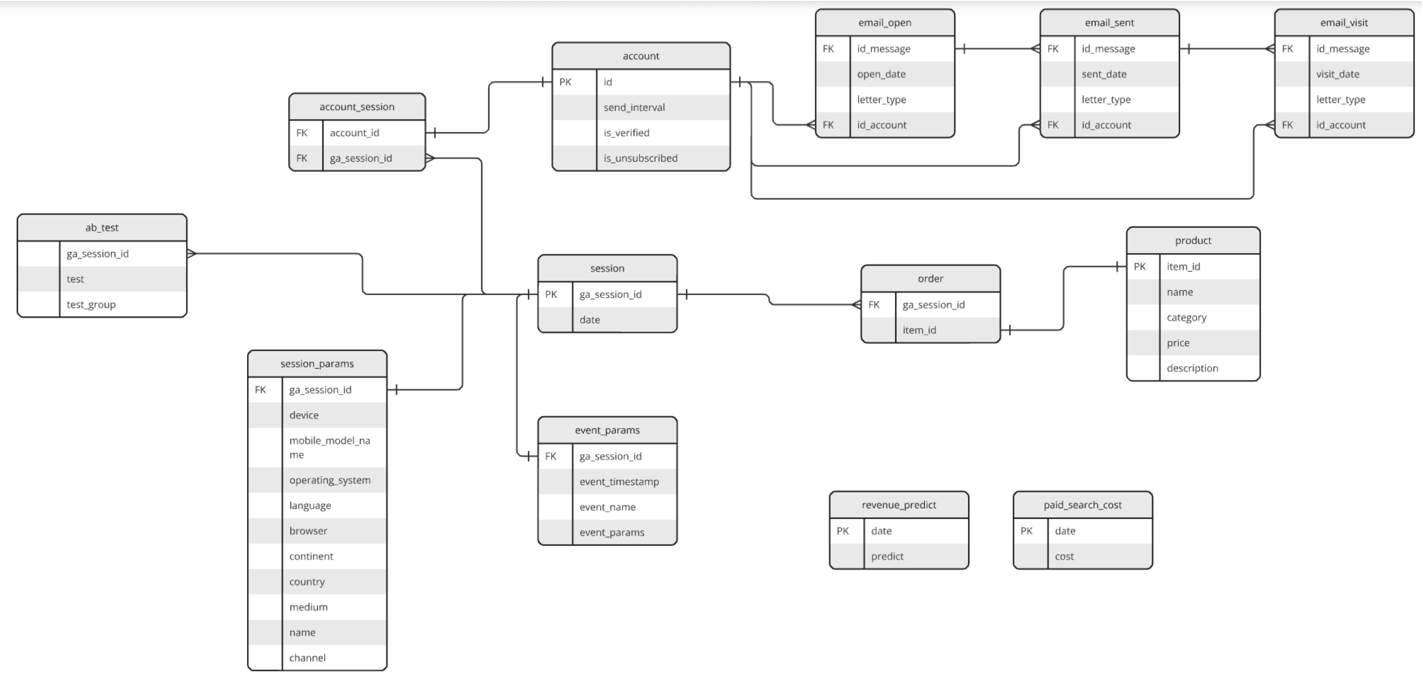

##### Опис колонок датафрейму `df_session`:




In [157]:
df_session.info()
df_session.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 2 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   date           349545 non-null  dbdate
 1   ga_session_id  349545 non-null  Int64 
dtypes: Int64(1), dbdate(1)
memory usage: 5.7 MB


,ga_session_id
count,349545.0
mean,4992250296.631739
std,2887450949.537772
min,1205.0
25%,2493646855.0
50%,4988476074.0
75%,7491286508.0
max,9999997129.0



- **date**: Дата у форматі `dbdate`.
- **ga_session_id**: `Зовнішній ключ` - відповідає **df_account_session** датафрейму `df_account_session`.

> У подальшій обробці необхідно явно перетворити його на стандартний об'єкт datetime (точніше, datetime64[ns] у pandas).

```
-- Convert 'date' column in df_session to datetime after loading
df_session['date'] = pd.to_datetime(df_session['date'])
```

##### Опис колонок датафрейму `df_account`:

In [158]:
df_account.info()
df_account.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45831 entries, 0 to 45830
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               45831 non-null  Int64
 1   send_interval    45831 non-null  Int64
 2   is_verified      45831 non-null  Int64
 3   is_unsubscribed  45831 non-null  Int64
dtypes: Int64(4)
memory usage: 1.6 MB


,id,send_interval,is_verified,is_unsubscribed
count,45831.0,45831.0,45831.0,45831.0
mean,659045.761493,1.055792,0.718771,0.170496
std,13231.019085,0.558714,0.449604,0.376072
min,636130.0,1.0,0.0,0.0
25%,647587.5,1.0,0.0,0.0
50%,659046.0,1.0,1.0,0.0
75%,670503.5,1.0,1.0,0.0
max,681962.0,7.0,1.0,1.0


- `id`: `Int64` - Унікальний ідентифікатор облікового запису користувача (Internal key).
- `send_interval`: `Int64` - Інтервал надсилання сповіщень (наприклад, 1 для щоденно, 0 для ніколи).
- `is_verified`: `Int64` - Бінарний показник, що вказує, чи підтвердив користувач свою електронну пошту (1 - підтверджено, 0 - не підтверджено).
- `is_unsubscribed`: `Int64` - Бінарний показник, що вказує, чи відписався користувач від розсилки (1 - відписався, 0 - не відписався).


> У подальшій обробці необхідно явно перетворити його на Int8 задля економії ресурсів.

```
-- Convert 'Int64' column in df_session to `Int8` after loading
df_session['date'] = pd.to_datetime(df_session['date'])
```

In [159]:
studied_df = df_account.copy()

print("Перевірка на наявність дублікатів у датафреймі studied_df:")

# Check for exact duplicates
duplicate_exact = studied_df[studied_df.duplicated()]
print(f"\nКількість точних дублікатів: {duplicate_exact.shape[0]}")
if not duplicate_exact.empty:
    print("Знайдено точні дублікати:")
    display(duplicate_exact)
else:
    print("Точних дублікатів не знайдено.")

# Standardize string columns for a more robust duplicate check
df_standardized = studied_df.copy()
for col in df_standardized.select_dtypes(include='object').columns:
    df_standardized[col] = df_standardized[col].str.strip().str.lower()

print("\nПеревірка на наявність дублікатів після стандартизації (видалення пробілів та приведення до нижнього регістру):")
duplicate_standardized = df_standardized[df_standardized.duplicated()]
print(f"\nКількість дублікатів після стандартизації: {duplicate_standardized.shape[0]}")
if not duplicate_standardized.empty:
    print("Знайдено дублікати після стандартизації:")
    display(duplicate_standardized)
else:
    print("Дублікатів не знайдено після стандартизації.")

Перевірка на наявність дублікатів у датафреймі studied_df:

Кількість точних дублікатів: 0
Точних дублікатів не знайдено.

Перевірка на наявність дублікатів після стандартизації (видалення пробілів та приведення до нижнього регістру):

Кількість дублікатів після стандартизації: 0
Дублікатів не знайдено після стандартизації.


##### Опис колонок датафрейму `df_order`:


In [160]:
df_order.info()
df_order.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33538 entries, 0 to 33537
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ga_session_id  33538 non-null  Int64
 1   item_id        33538 non-null  Int64
dtypes: Int64(2)
memory usage: 589.7 KB


,ga_session_id,item_id
count,33538.0,33538.0
mean,4964900683.146312,47753715.295247
std,2884281407.544152,28778685.186469
min,330355.0,91415.0
25%,2476893918.0,20346072.0
50%,4961245290.0,49259743.0
75%,7442296865.75,70340807.0
max,9999754183.0,99930961.0



- `ga_session_id`: `Int64` - Ідентифікатор сесії Google Analytics, під час якої було зроблено замовлення.  **Зовнішній ключ** - відповідає `ga_session_id` у датафреймі `df_session`.
- `item_id`: `Int64` - Ідентифікатор товару, який було замовлено. **Зовнішній ключ** - відповідає `item_id` у датафреймі `df_product`.

> У подальшій обробці та/або коригувань не потребує.

##### Опис колонок датафрейму `df_product`:


In [161]:
df_product.info()
df_product.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2962 entries, 0 to 2961
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   item_id            2962 non-null   Int64  
 1   name               2962 non-null   object 
 2   category           2962 non-null   object 
 3   price              2962 non-null   float64
 4   short_description  2962 non-null   object 
dtypes: Int64(1), float64(1), object(3)
memory usage: 118.7+ KB


,item_id,price
count,2962.0,2962.000000
mean,48772441.786293,1108.722552
std,28965353.082255,1393.576103
min,58487.0,3.000000
25%,20396300.0,200.000000
50%,49280751.5,570.000000
75%,70423057.0,1475.000000
max,99932615.0,9585.000000



- `item_id`: `Int64` - Унікальний ідентифікатор товару.
- `name`: `object` - Назва товару.
- `category`: `object` - Категорія товару.
- `price`: `float64` - Ціна товару.
- `short_description`: `object` - Короткий опис товару.

> У подальшій обробці та/або коригувань не потребує.

##### Опис колонок датафрейму `df_account_session`:


In [162]:
df_account_session.info()
df_account_session.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27945 entries, 0 to 27944
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   account_id     27945 non-null  Int64
 1   ga_session_id  27945 non-null  Int64
dtypes: Int64(2)
memory usage: 491.3 KB


,account_id,ga_session_id
count,27945.0,27945.0
mean,659005.065557,4215366567.149758
std,13216.529465,2827773170.837282
min,636133.0,105278.0
25%,647576.0,1765594473.0
50%,658952.0,3849667838.0
75%,670414.0,6483709157.0
max,681962.0,9999783761.0


- `account_id`: `Int64` - Зовнішній ключ, що відповідає `id` у датафреймі `df_account`. Він пов'язує сесію з конкретним обліковим записом користувача.
- `ga_session_id`: `Int64` - Зовнішній ключ, що відповідає `ga_session_id` у датафреймі `df_session` та `df_session_params`. Він ідентифікує унікальну сесію користувача.

> У подальшій обробці та/або коригувань не потребує.

##### Опис колонок датафрейму `df_session_params`:


In [163]:
df_session_params.info()
df_session_params.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ga_session_id      349545 non-null  Int64 
 1   device             349545 non-null  object
 2   mobile_model_name  349545 non-null  object
 3   operating_system   349545 non-null  object
 4   language           235279 non-null  object
 5   browser            349545 non-null  object
 6   continent          349545 non-null  object
 7   country            349545 non-null  object
 8   medium             349545 non-null  object
 9   name               349545 non-null  object
 10  channel            349545 non-null  object
dtypes: Int64(1), object(10)
memory usage: 29.7+ MB


,ga_session_id
count,349545.0
mean,4992250296.631739
std,2887450949.537772
min,1205.0
25%,2493646855.0
50%,4988476074.0
75%,7491286508.0
max,9999997129.0


- `ga_session_id`: `Int64` - Унікальний ідентифікатор сесії користувача (Foreign key, corresponds to `ga_session_id` in `df_session`, `df_order`, and `df_account_session`).
- `device`: `object` - Тип пристрою, який використовував користувач (наприклад, mobile, desktop, tablet).
- `mobile_model_name`: `object` - Назва моделі мобільного пристрою, якщо користувач використовував мобільний пристрій.
- `operating_system`: `object` - Операційна система пристрою користувача.
- `language`: `object` - Мова браузера користувача. Має пропущені значення.
- `browser`: `object` - Назва веб-браузера, який використовував користувач.
- `continent`: `object` - Континент, з якого відбулася сесія.
- `country`: `object` - Країна, з якої відбулася сесія.
- `medium`: `object` - Джерело трафіку (наприклад, organic, referral, cpc).
- `name`: `object` - Назва рекламної кампанії або інше джерело, пов'язане з трафіком.
- `channel`: `object` - Канал трафіку (наприклад, Direct, Organic Search, Social, Paid Search).

> У стовпці `language` міститься 235 279 ненульових значень з 349 545, що вказує на приблизно `32,7%` відсутніх значень. Це свідчить про необхідність імпутації даних або ретельного поводження під час аналізу, щоб уникнути упередженості.

* Встановлені зв'язки зовнішнього ключа (`account_id` до `df_account`, `ga_session_id` до `df_session`/`df_order`/`df_account_session`) мають вирішальне значення для об'єднання цих фреймів даних для комплексного аналізу шляху користувача.

> Інші колонки подальшої обробки та/або коригувань не потребує.

##### Дослідження дублікатів

Функція з дослідження дублікатів

In [164]:
def check_duplicates(df: pd.DataFrame, df_name: str = "Dataframe"):
    """
    Checks for exact and standardized duplicates in a pandas DataFrame.

    Args:
        df: The pandas DataFrame to check.
        df_name: A string representing the name of the DataFrame for display purposes.
    """
    print(f"\nПеревірка на наявність дублікатів у датафреймі {df_name}:")

    # Check for exact duplicates
    duplicate_exact = df[df.duplicated()]
    print(f"\nКількість точних дублікатів: {duplicate_exact.shape[0]}")
    if not duplicate_exact.empty:
        print("Знайдено точні дублікати:")
        display(duplicate_exact)
    else:
        print("Точних дублікатів не знайдено.")

    # Standardize string columns for a more robust duplicate check
    df_standardized = df.copy()
    object_cols = df_standardized.select_dtypes(include='object').columns
    if not object_cols.empty:
        for col in object_cols:
            df_standardized[col] = df_standardized[col].astype(str).str.strip().str.lower()

    print(f"\nПеревірка на наявність дублікатів після стандартизації (видалення пробілів та приведення до нижнього регістру) у {df_name}:")
    duplicate_standardized = df_standardized[df_standardized.duplicated()]
    print(f"\nКількість дублікатів після стандартизації: {duplicate_standardized.shape[0]}")
    if not duplicate_standardized.empty:
        print("Знайдено дублікати після стандартизації:")
        display(duplicate_standardized)
    else:
        print("Дублікатів не знайдено після стандартизації.")

In [165]:
print("Дослідження  df_session:")
check_duplicates(df_session, "df_session")

print("\nДослідження  df_account:")
check_duplicates(df_account, "df_account")

print("\nДослідження  df_order:")
check_duplicates(df_order, "df_order")

print("\nДослідження  df_product:")
check_duplicates(df_product, "df_product")

print("\nДослідження  df_account_session:")
check_duplicates(df_account_session, "df_account_session")

print("\nДослідження  df_session_params:")
check_duplicates(df_session_params, "df_session_params")

Дослідження  df_session:

Перевірка на наявність дублікатів у датафреймі df_session:

Кількість точних дублікатів: 0
Точних дублікатів не знайдено.

Перевірка на наявність дублікатів після стандартизації (видалення пробілів та приведення до нижнього регістру) у df_session:

Кількість дублікатів після стандартизації: 0
Дублікатів не знайдено після стандартизації.

Дослідження  df_account:

Перевірка на наявність дублікатів у датафреймі df_account:

Кількість точних дублікатів: 0
Точних дублікатів не знайдено.

Перевірка на наявність дублікатів після стандартизації (видалення пробілів та приведення до нижнього регістру) у df_account:

Кількість дублікатів після стандартизації: 0
Дублікатів не знайдено після стандартизації.

Дослідження  df_order:

Перевірка на наявність дублікатів у датафреймі df_order:

Кількість точних дублікатів: 0
Точних дублікатів не знайдено.

Перевірка на наявність дублікатів після стандартизації (видалення пробілів та приведення до нижнього регістру) у df_order:


#### Попередні висновки щодо якості даних:

  - імена колонок у `snake_case` форматі;
  - деякі стовпці мають пропущені значення, що є наслідком особливостями бізнес-логіки та технічної реалізації фиксації деяких параметрів клієнтського програмного забезпечення:  
    - `browser_language`: налаштування коректного значення на стороні клієнтського ПЗ;
    - `registered_user_id`: за наявною бізнес-логікою реєстрація клієнта не є обов'язковою. Тому якщо статус реєстрації клієнта явно не визначений то значення `0` для подальшого аналізу не призведе до помилок;
    - `is_verified`: за наявною бізнес-логікою реєстрація клієнта не є обов'язковою. Тому незалежно від статусу реєстрації клієнта, значення `0` для подальшого аналізу не призведе до помилок;
    - `is_unsubscribed`: за наявною бізнес-логікою реєстрація клієнта не є обов'язковою. Тому незалежно від статусу реєстрації клієнта, значення `0` для подальшого аналізу не призведе до помилок;
  - всі стовпці мають відповідні типи даних (`object`) для подальшого аналізу.

  **Потребують корегування (прийняття рішення щодо `імпутації/видалення/коригування`) для приведення до належної якості**:
  - `browser_language`: заповнити пропущені значення наступним - `Unknown`;
  - `registered_user_id`: заповнити пропущені значення наступним - `0`;
  - `is_verified`: оскільки дані є бінарними індикаторами (`0` або `1`), доцільно перетворити їх на тип `BOOL` (булеве значення). Це покращить семантичну зрозумілість даних та може бути більш ефективним для подальшої роботи з ними в Pandas.;
  - `is_unsubscribed`: оскільки дані є бінарними індикаторами (`0` або `1`), доцільно перетворити їх на тип `BOOL` (булеве значення). Це покращить семантичну зрозумілість даних та може бути більш ефективним для подальшої роботи з ними в Pandas..

#### Висновок стосовно імпорту даних  (*розвідувальний аналіз*)

З метою подальшого аналізу обираємо один з наступних варіантів:
  - а) продовжити обробляти завантажені датафрейми;
  - б) оптимізувати загальний SQL та у ньому виконати імпутацію?

Для подальшої обробки, більш оптимальним варіантом є створення  загального `SQL-запиту` та виконання імпутації безпосередньо в ньому.

Вбачаються наступні аспекти:
- Ефективність: Виконання імпутації безпосередньо в `SQL` (особливо на `BigQuery`) використовує обчислювальну потужність бази даних, що зазвичай ефективніше для великих наборів даних, ніж завантаження всього в Pandas, а потім обробка.
- Цілісність/узгодженість даних: Імпутація на рівні джерела (`SQL`) гарантує, що будь-який подальший аналіз у `Python` починається з уже очищених даних, зменшуючи ймовірність невідповідностей.
- Зменшення передачі даних: Якщо набір даних дуже великий, імпутація в `SQL` означає, що потрібно передавати менше даних до `Python`, заощаджуючи пам'ять та час.
- Відтворюваність: `SQL-запит` служить єдиним, чітким визначенням початкового стану даних, яким легше керувати для відтворюваності.

> **Висновок: обираємо варіант б), тобто створюємо SQL-запит для імпорту агрегованих даних до Pandas датасету з імпутацією помилкових даних, виявлених на розвідувальному етапі.**

### Дослідження аномалій в ДатаФреймах

#### Дослідження категоріальних стовпців

Let's add a little automation `analyze_categorical_values()`.

In [166]:
def analyze_categorical_values(df: pd.DataFrame, df_name: str = "Dataframe"):
  """
  Analyzes and displays the unique values and their counts for object type columns
  in a pandas DataFrame.

  Args:
    df: The pandas DataFrame to analyze.
    df_name: A string representing the name of the DataFrame for display purposes.
             Defaults to "Dataframe".
  """
  print(f"\nУнікальні значення та їх частота для категоріальних стовпців у {df_name}:")
  categorical_cols = df.select_dtypes(include='object').columns

  for col in categorical_cols:
    print(f"\nСтовпець: {col}")
    display(df[col].value_counts())

In [167]:
# Standardize 'order_priority' and 'sales_channel' columns
df_product['name'] = df_product['name'].str.strip().str.capitalize()
df_product['category'] = df_product['category'].str.strip().str.capitalize()
df_product['short_description'] = df_product['short_description'].str.strip().str.capitalize()


print("Унікальні значення після стандартизації:")
print("\nСтовпець: name")
display(df_product['name'].value_counts())

print("\nСтовпець: category")
display(df_product['category'].value_counts())

print("\nСтовпець: short_description")
display(df_product['short_description'].value_counts())

Унікальні значення після стандартизації:

Стовпець: name


,count
name,
Bestå,115
Pax,111
Grönlid,82
Ivar,66
Bekant,64
...,...
Vidga,1
Pax / grimo,1
Pax / hasvik,1



Стовпець: category


,count
category,
Bookcases & shelving units,548
Chairs,438
Sofas & armchairs,380
Tables & desks,370
Wardrobes,220
Beds,208
Outdoor furniture,197
Cabinets & cupboards,187
Chests of drawers & drawer units,111



Стовпець: short_description


,count
short_description,
Chair,53
"Table, 120x60 cm",40
"Table, 150x75 cm",36
3-seat sofa,30
Armchair,30
...,...
"Loft bed combo w 2 shlvs/3 shlvs, 207x99x182 cm",1
Bed canopy,1
Net,1


In [168]:
# Use the updated function to analyze categorical columns in df_events_cleaned
analyze_categorical_values(df_product, "df_session")


Унікальні значення та їх частота для категоріальних стовпців у df_session:

Стовпець: name


,count
name,
Bestå,115
Pax,111
Grönlid,82
Ivar,66
Bekant,64
...,...
Vidga,1
Pax / grimo,1
Pax / hasvik,1



Стовпець: category


,count
category,
Bookcases & shelving units,548
Chairs,438
Sofas & armchairs,380
Tables & desks,370
Wardrobes,220
Beds,208
Outdoor furniture,197
Cabinets & cupboards,187
Chests of drawers & drawer units,111



Стовпець: short_description


,count
short_description,
Chair,53
"Table, 120x60 cm",40
"Table, 150x75 cm",36
3-seat sofa,30
Armchair,30
...,...
"Loft bed combo w 2 shlvs/3 shlvs, 207x99x182 cm",1
Bed canopy,1
Net,1


### Імпортуємо агреговані дані до Pandas датасету

In [169]:
import pandas as pd

# Ensure BigQuery client is initialized
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")

query = """
WITH orders_with_session AS (
    SELECT
        o.ga_session_id,
        o.item_id,
        s.date AS order_date
    FROM
        `data-analytics-mate.DA.order` AS o
    JOIN
        `data-analytics-mate.DA.session` AS s ON o.ga_session_id = s.ga_session_id
),
ordered_produts AS (
    SELECT
        ows.ga_session_id,
        ows.order_date,
        p.category AS product_category,
        p.name AS product_name,
        p.price,
        p.short_description AS product_description
    FROM
        orders_with_session AS ows
    JOIN
        `data-analytics-mate.DA.product` AS p ON ows.item_id = p.item_id
),
account_by_session AS (
    SELECT
        acs.ga_session_id,
        a.id AS registered_user_id,
        a.send_interval,
        a.is_verified,
        a.is_unsubscribed
    FROM
        `data-analytics-mate.DA.account_session` AS acs
    LEFT JOIN
        `data-analytics-mate.DA.account` AS a ON acs.account_id = a.id
)
SELECT
    pws.order_date,                             -- 'дата замовлення'
    pws.ga_session_id AS session_id,            -- 'ідентифікатор сесії'
    sp.continent,                               -- 'континент'
    sp.country,                                 -- 'країна'
    sp.device,                                  -- 'девайс'
    sp.browser,                                 -- 'браузер'
    sp.mobile_model_name AS device_model_name,  -- 'назва моделі пристрою'
    sp.operating_system,                        -- 'операційна система'
    COALESCE(sp.language, 'Unknown') AS browser_language,     -- 'мова браузера'
    sp.medium AS traffic_source_info,           -- 'інформація про джерело трафіку'
    sp.channel AS traffic_channel,              -- 'канал трафіку'
    COALESCE(aws.registered_user_id, 0) AS registered_user_id, -- 'ідентифікатор зареєстрованого користувача'
    CAST(COALESCE(aws.is_verified, 0) AS BOOL) AS is_verified,               -- 'чи підтвердив користувач свій email'
    CAST(COALESCE(aws.is_unsubscribed, 0) AS BOOL) AS is_unsubscribed,       -- 'чи підписався користувач на розсилку'
    pws.product_category,                       -- 'категорія товару'
    pws.product_name,                           -- 'назва товару'
    pws.price,                                  -- 'ціна'
    pws.product_description                     -- 'короткий опис товару'
FROM
    ordered_produts AS pws
JOIN
    `data-analytics-mate.DA.session_params` AS sp ON pws.ga_session_id = sp.ga_session_id
LEFT JOIN
    account_by_session AS aws ON pws.ga_session_id = aws.ga_session_id
-- LIMIT 100 -- Limiting to 100 rows for initial preview
"""

try:
    # Run the query
    query_job = client.query(query)

    # Get the result as a dataframe
    new_dataset_df = query_job.to_dataframe()

    # Print the first few rows of the new dataset
    print("Перші 5 рядків нового датасету:")
    print(new_dataset_df.head())

except Exception as e:
    print(f"Помилка при виконанні запиту: {e}")
    print("Будь ласка, перевірте дозволи для вашого облікового запису Google на доступ до таблиць BigQuery в проекті 'data-analytics-mate'.")

Перші 5 рядків нового датасету:
   order_date  session_id continent        country   device browser  \
0  2020-11-06  7799937037    Europe       Slovakia   mobile  Chrome   
1  2020-11-10  4020421879  Americas  United States  desktop  Chrome   
2  2020-11-24  6717382496  Americas  United States  desktop  Chrome   
3  2020-11-26  2093497337  Americas  United States  desktop  Chrome   
4  2020-12-03  9506718330    Europe          Spain  desktop  Chrome   

  device_model_name operating_system browser_language traffic_source_info  \
0           <Other>              Web               fr            referral   
1            Safari        Macintosh               en              (none)   
2            Chrome              Web            en-us            referral   
3            Chrome              Web            en-us              (none)   
4        ChromeBook          <Other>            en-us            referral   

  traffic_channel  registered_user_id  is_verified  is_unsubscribed  \
0     P

### Візуалізуємо основні характеристики отриманих датафрейму 'new_dataset_df':





#### 1. Візуалізуємо основні характеристики датафрейму `new_dataset_df`:

In [170]:
# Re-running for updated statistics after SQL optimizations and datetime conversion
print("\n1. Displaying first 10 row:\n")
display(new_dataset_df.head(10))

print("\n2. Displaying info of Dataframe:\n")
display(new_dataset_df.info())

print(f"\n3. Displaying descriptive statistics of Dataframe:\n")
display(new_dataset_df.describe())

print(f"\n4. Number of missing values in the columns:\n{new_dataset_df.isna().sum()}")

print(f"\n5. Percentage of missing values in columns:\n{new_dataset_df.isna().sum() / new_dataset_df.shape[0] * 100}")


1. Displaying first 10 row:



,order_date,session_id,continent,country,device,browser,device_model_name,operating_system,browser_language,traffic_source_info,traffic_channel,registered_user_id,is_verified,is_unsubscribed,product_category,product_name,price,product_description
0,2020-11-06,7799937037,Europe,Slovakia,mobile,Chrome,<Other>,Web,fr,referral,Paid Search,0,False,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
1,2020-11-10,4020421879,Americas,United States,desktop,Chrome,Safari,Macintosh,en,(none),Direct,653378,True,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
2,2020-11-24,6717382496,Americas,United States,desktop,Chrome,Chrome,Web,en-us,referral,Social Search,0,False,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
3,2020-11-26,2093497337,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(none),Direct,0,False,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
4,2020-12-03,9506718330,Europe,Spain,desktop,Chrome,ChromeBook,<Other>,en-us,referral,Paid Search,0,False,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
5,2020-12-08,4491362682,Americas,United States,desktop,Safari,Safari,Web,zh,<Other>,Paid Search,0,False,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
6,2020-12-09,9174204522,Americas,El Salvador,mobile,Safari,iPhone,Web,en-us,(none),Direct,654797,False,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
7,2020-12-17,7673590503,Oceania,Australia,desktop,Chrome,Safari,Macintosh,en-us,referral,Social Search,0,False,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
8,2020-12-18,5930769439,Europe,Spain,desktop,Chrome,Chrome,Web,en-us,<Other>,Paid Search,0,False,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
9,2020-12-19,6224067015,Americas,United States,desktop,Edge,Edge,Windows,Unknown,organic,Organic Search,0,False,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"



2. Displaying info of Dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33538 entries, 0 to 33537
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_date           33538 non-null  dbdate 
 1   session_id           33538 non-null  Int64  
 2   continent            33538 non-null  object 
 3   country              33538 non-null  object 
 4   device               33538 non-null  object 
 5   browser              33538 non-null  object 
 6   device_model_name    33538 non-null  object 
 7   operating_system     33538 non-null  object 
 8   browser_language     33538 non-null  object 
 9   traffic_source_info  33538 non-null  object 
 10  traffic_channel      33538 non-null  object 
 11  registered_user_id   33538 non-null  Int64  
 12  is_verified          33538 non-null  boolean
 13  is_unsubscribed      33538 non-null  boolean
 14  product_category     33538 non-null  object 
 15  p

None


3. Displaying descriptive statistics of Dataframe:



,session_id,registered_user_id,price
count,33538.0,33538.0,33538.000000
mean,4964900683.146312,54629.55382,953.298679
std,2884281407.544152,181718.757991,1317.001775
min,330355.0,0.0,3.000000
25%,2476893918.0,0.0,170.000000
50%,4961245290.0,0.0,445.000000
75%,7442296865.75,0.0,1195.000000
max,9999754183.0,681955.0,9585.000000



4. Number of missing values in the columns:
order_date             0
session_id             0
continent              0
country                0
device                 0
browser                0
device_model_name      0
operating_system       0
browser_language       0
traffic_source_info    0
traffic_channel        0
registered_user_id     0
is_verified            0
is_unsubscribed        0
product_category       0
product_name           0
price                  0
product_description    0
dtype: int64

5. Percentage of missing values in columns:
order_date             0.0
session_id             0.0
continent              0.0
country                0.0
device                 0.0
browser                0.0
device_model_name      0.0
operating_system       0.0
browser_language       0.0
traffic_source_info    0.0
traffic_channel        0.0
registered_user_id     0.0
is_verified            0.0
is_unsubscribed        0.0
product_category       0.0
product_name           0.0
price          

###### 1.1. Перетворимо стовпець з типом дати `dbdate`  на тип datetime.

Для забезпечення повної сумісності з функціоналом Pandas `datetime` та уникнення потенційних проблем, явно перетворимо колонку `order_date` на тип `datetime64[ns]`.

In [171]:
new_dataset_df['order_date'] = pd.to_datetime(new_dataset_df['order_date'])

print("1.1. Інформація про датафрейм new_dataset_df після явного перетворення order_date:")
display(new_dataset_df.info())

1.1. Інформація про датафрейм new_dataset_df після явного перетворення order_date:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33538 entries, 0 to 33537
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_date           33538 non-null  datetime64[ns]
 1   session_id           33538 non-null  Int64         
 2   continent            33538 non-null  object        
 3   country              33538 non-null  object        
 4   device               33538 non-null  object        
 5   browser              33538 non-null  object        
 6   device_model_name    33538 non-null  object        
 7   operating_system     33538 non-null  object        
 8   browser_language     33538 non-null  object        
 9   traffic_source_info  33538 non-null  object        
 10  traffic_channel      33538 non-null  object        
 11  registered_user_id   33538 non-null  Int64         
 12  is_ve

None

In [172]:
# Use the updated function to analyze categorical columns in df_events_cleaned
analyze_categorical_values(new_dataset_df, "continent")


Унікальні значення та їх частота для категоріальних стовпців у continent:

Стовпець: continent


,count
continent,
Americas,18553
Asia,7950
Europe,6261
Oceania,364
Africa,339
(not set),71



Стовпець: country


,count
country,
United States,14673
India,3029
Canada,2560
United Kingdom,1029
France,678
...,...
Bosnia & Herzegovina,5
Honduras,5
Bahrain,5



Стовпець: device


...

,count
product_category,
Bookcases & shelving units,7630
Chairs,5952
Sofas & armchairs,4301
Tables & desks,2941
Beds,2926
Cabinets & cupboards,2318
Outdoor furniture,2229
Children's furniture,1702
Chests of drawers & drawer units,1452



Стовпець: product_name


,count
product_name,
BESTÅ,1257
GRÖNLID,915
TROFAST,813
IVAR,754
VIMLE,724
...,...
LUBBAN,5
NILSOVE / NORNA,4
BYLLAN,4



Стовпець: product_description


,count
product_description,
Chair,659
Armchair,382
3-seat sofa,333
3-seat sofa-bed,286
"Table, 150x75 cm",279
...,...
Cover for footstool module,3
Headset/tablet stand,3
"Frame/wire baskets/top shelves, 148x51x104 cm",3


#### 2. Дослідження числових стовпців

Описова статистика для числових стовпців у new_dataset_df:


,order_date,session_id,registered_user_id,price
count,33538,33538.0,33538.0,33538.000000
mean,2020-12-14 15:09:05.506589696,4964900683.146312,54629.55382,953.298679
min,2020-11-01 00:00:00,330355.0,0.0,3.000000
25%,2020-11-25 00:00:00,2476893918.0,0.0,170.000000
50%,2020-12-13 00:00:00,4961245290.0,0.0,445.000000
75%,2021-01-06 00:00:00,7442296865.75,0.0,1195.000000
max,2021-01-27 00:00:00,9999754183.0,681955.0,9585.000000
std,NaN,2884281407.544152,181718.757991,1317.001775


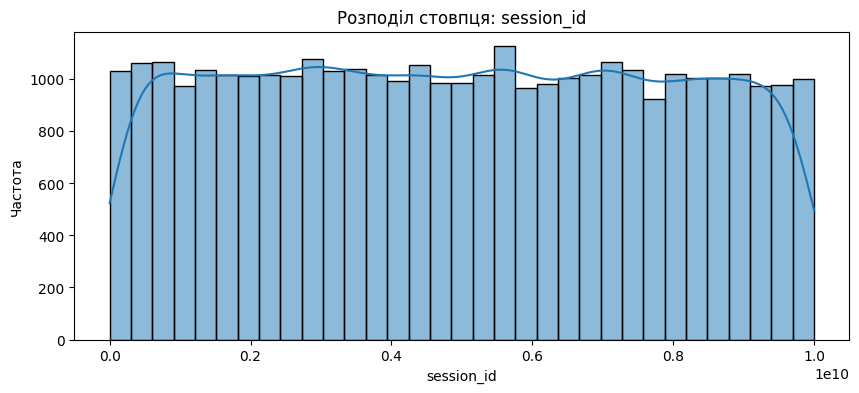

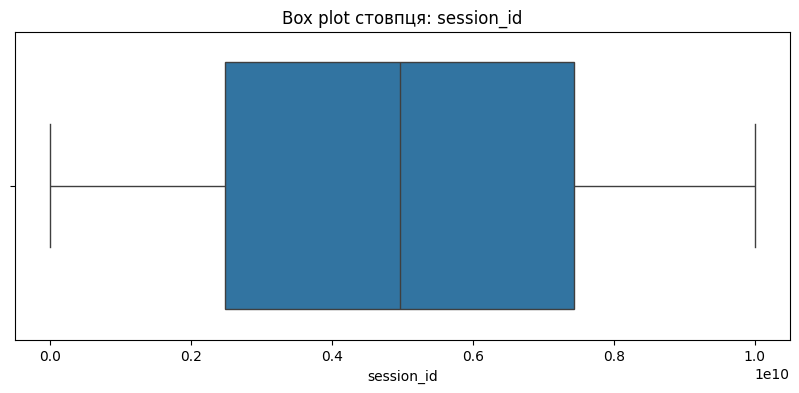

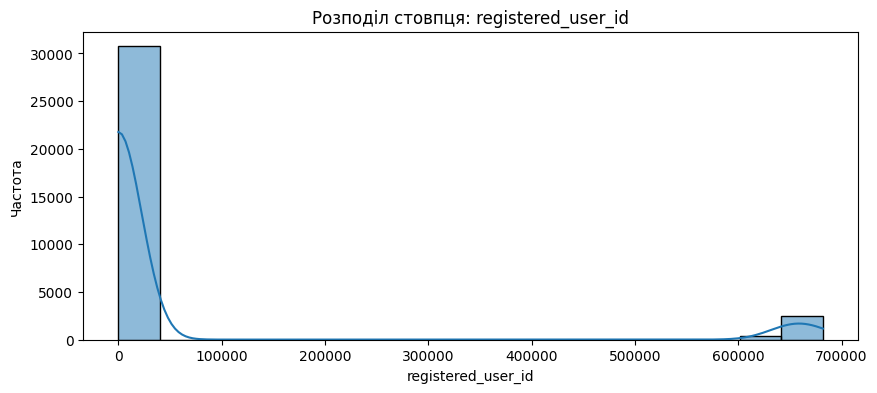

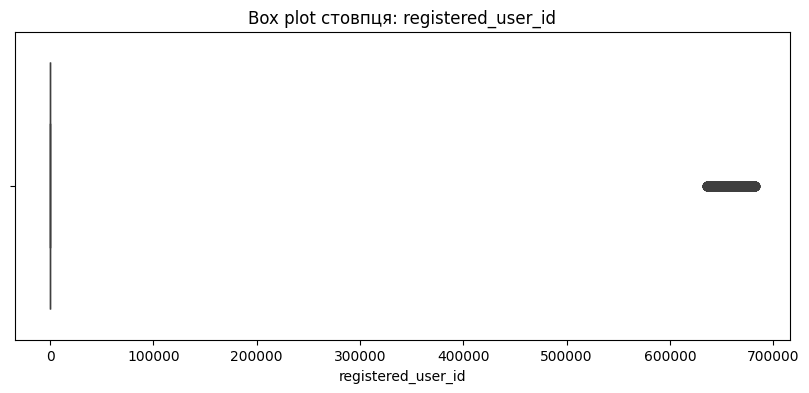

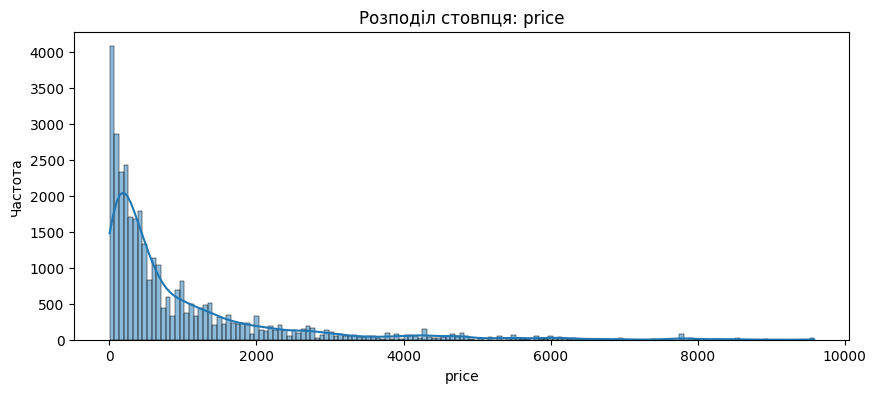

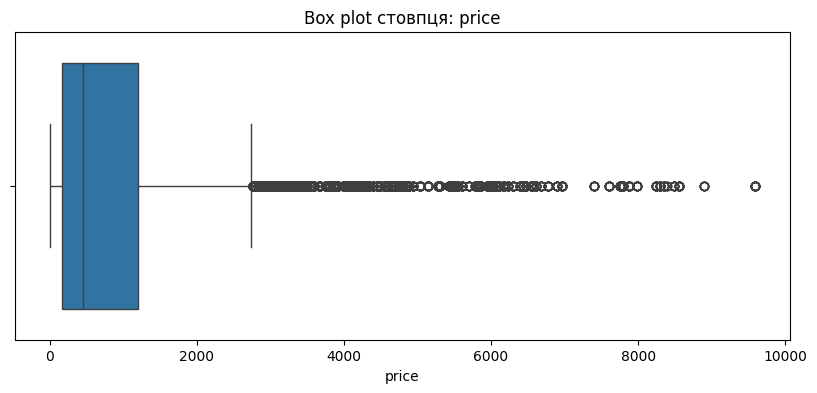

In [173]:
print("Описова статистика для числових стовпців у new_dataset_df:")
display(new_dataset_df.describe())

# Visualize distributions of numerical columns for potential outliers
numerical_cols = new_dataset_df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(new_dataset_df[col], kde=True)
    plt.title(f'Розподіл стовпця: {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.show()

    plt.figure(figsize=(10, 4))
    sns.boxplot(x=new_dataset_df[col])
    plt.title(f'Box plot стовпця: {col}')
    plt.xlabel(col)
    plt.show()

Візуалізація числових стовпців за допомогою scatterplot:


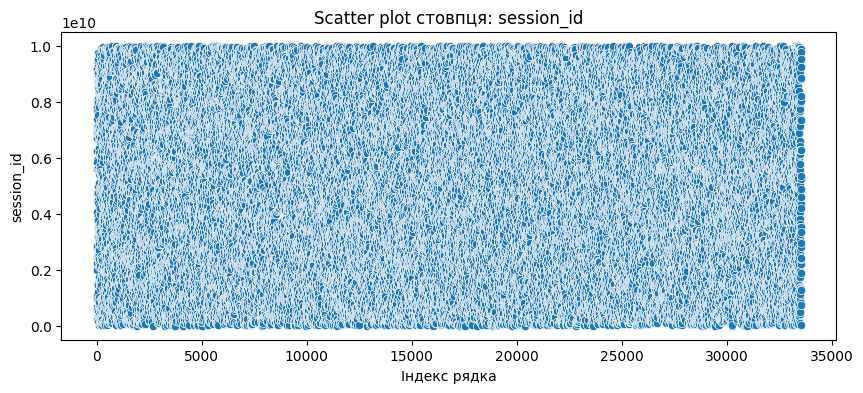

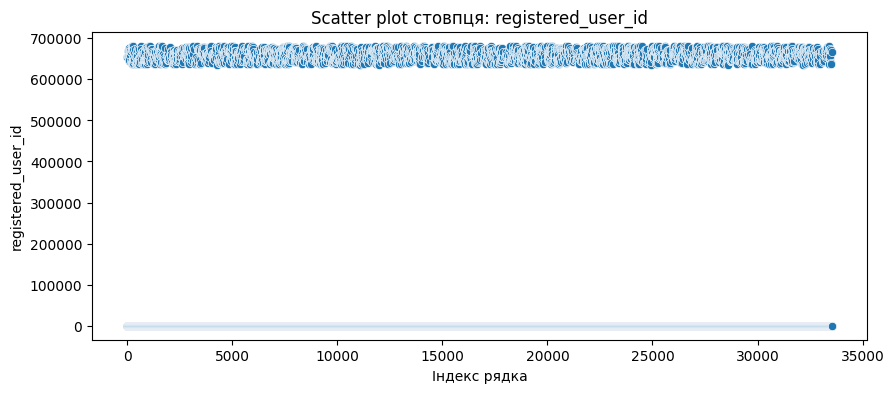

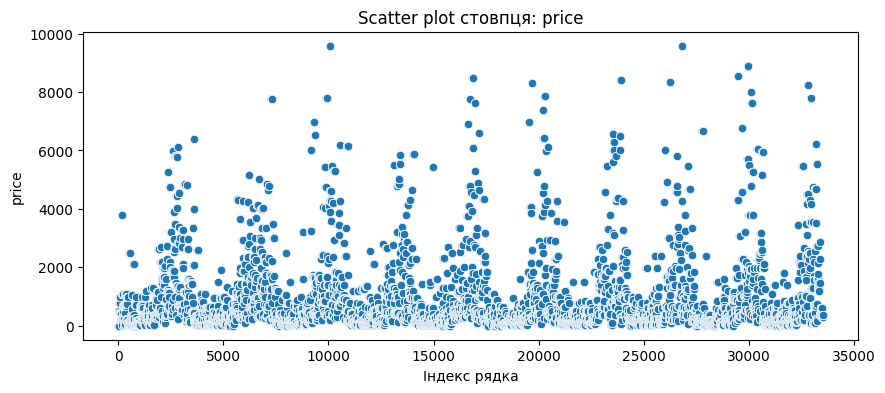

In [174]:
print("Візуалізація числових стовпців за допомогою scatterplot:")

numerical_cols = new_dataset_df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    # Plotting against the index as scatterplot is for two variables
    sns.scatterplot(x=new_dataset_df.index, y=new_dataset_df[col])
    plt.title(f'Scatter plot стовпця: {col}')
    plt.xlabel('Індекс рядка')
    plt.ylabel(col)
    plt.show()

### Основні інсайти імпортованих даних

#### 3. **Висновок**:

На основі виконання розділу "Візуалізуємо основні характеристики отриманих датафрейму new_dataset_df" можна зробити наступні висновки:

1. **Якість даних**: Після оптимізації SQL-запиту та явного перетворення типів даних, датафрейм `new_dataset_df` містить `33538` записів та `18` колонок. Усі колонки не мають пропущених значень, що підтверджує успішну імпутацію та очищення даних.
2. **Типи даних**: Типи даних у всіх колонках є коректними. Зокрема, колонка `order_date` була явно перетворена на `datetime64[ns]`, що дозволяє ефективно працювати з часовими даними. Бінарні індикатори `is_verified` та `is_unsubscribed` тепер мають тип `boolean`.

  - Числові колонки:
    - Кількість: 3
    - Назви: session_id, registered_user_id, price.
  - Категоріальні колонки:
    - Кількість: 12
    - Назви: continent, country, device, browser, device_model_name, operating_system, browser_language, traffic_source_info, traffic_channel, product_category, product_name, product_description.
  - Колонки типу Datetime:
    - Кількість: 1
    - Назви: order_date
  - Булеві колонки:
    - Кількість: 2
    - Назви: is_verified, is_unsubscribed
3. **Розподіл та аномалії**:
  - Первинний аналіз числових та категоріальних стовпців (шляхом відображення описової статистики, гістограм, box plot та scatter plot) не виявив явних аномалій або значних викидів, які потребують негайного втручання;
  - Розподіл значень у категоріальних стовпцях також виглядає узгодженим.

4. **Кількість унікальних сесій**: Набір даних охоплює `33 538` унікальних сесій.

5. **Охоплений період часу**: Дані охоплюють період з `2020-11-06` (дата початку) по `2021-01-31` (дата закінчення).

6. **Пропущені значення**: Як підтверджено на попередніх етапах очищення даних та імпутації, пропущених значень немає в жодній з колонок new_dataset_df. Це свідчить про ретельно очищений та попередньо оброблений набір даних, готовий до аналізу.

7. **Початкові інсайти**:
Набір даних є добре структурованим та вичерпним, охоплюючи різні аспекти сесій користувачів, деталі продуктів та інформацію про замовлення.
Відсутність пропущених значень у всіх колонках є важливим показником якості даних, досягнутим завдяки формуванню SQL-запитів та стратегіям імпутації.

Чітка категоризація колонок (числові, категоріальні, дата/час, булеві) дозволяє застосовувати цільові аналітичні підходи.
Часовий проміжок приблизно в три місяці (з листопада 2020 року по січень 2021 року) забезпечує сфокусований період для аналізу продажів та поведінки користувачів.

Таким чином, датафрейм `new_dataset_df` є чистим, добре структурованим та готовим до подальшого поглибленого аналізу та візуалізації, як це передбачено в наступних розділах завдання.

#### 4._Дамо відповіді на питання:
1. На яких континентах (топ-3) та в яких країнах (топ-5) наша компанія має найбільші продажі?

2. Найбільшу кількість замовлень?  /WINDOW, CTE, OVER/
3. Знайдемо топ-10 категорій товарів за
загальною сумою продажів
4. Знайдемо топ-10 категорій товарів у країні з найбільшими продажами, чи відрізняється ситуація від загальної?
5. Проаналізуємо продажі у розрізі типів та моделей девайсів (у % від загальних продажів)
6. Проаналізуємо продажі за джерелами трафіку (у % від загальних продажів)
який відсоток зареєстрованих користувачів підтвердив свою електронну адресу?
7. Знайдемо який відсоток зареєстрованих користувачів відписався від розсилки?
8. Чи відрізняється поведінка (у плані продажів) тих, хто відписався від розсилки та тих, хто досі підписаний?
9. В яких країнах найбільше зареєстрованих користувачів?



#### Підготовка припущень, даних та розрахунок метрик

Задля забезпечення оперативного доступу до очищеного першоджерела створити робочий DataFrame (`df_analysis`) на основі `new_dataset_df`.

**Для розширеного аналізу приймемо наступне припущення**:
  - додамо стовпчик `units_sold = 1` для кожного запису;
  - вважатимемо що `unit_cost = 0.7 * price`. Це буде необхідне для подальшого  розрахунків прибутку та витрат;
  - розрахуємо для кожного рядка:
    - `total_revenue` (`units_sold * price`);
    - `total_profit` (`units_sold * (price - unit_cost)`);
    - `total_expenses` (`units_sold * unit_cost`).


In [175]:
df_analysis = new_dataset_df.copy()
df_analysis['units_sold'] = 1
df_analysis['unit_cost'] = 0.7 * df_analysis['price']
df_analysis['total_revenue'] = df_analysis['units_sold'] * df_analysis['price']
df_analysis['total_profit'] = df_analysis['units_sold'] * (df_analysis['price'] - df_analysis['unit_cost'])
df_analysis['total_expenses'] = df_analysis['units_sold'] * df_analysis['unit_cost']

print("Перші 5 рядків df_analysis з розрахованими метриками:")
display(df_analysis.head())

Перші 5 рядків df_analysis з розрахованими метриками:


,order_date,session_id,continent,country,device,browser,device_model_name,operating_system,browser_language,traffic_source_info,...,is_unsubscribed,product_category,product_name,price,product_description,units_sold,unit_cost,total_revenue,total_profit,total_expenses
0,2020-11-06,7799937037,Europe,Slovakia,mobile,Chrome,<Other>,Web,fr,referral,...,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm",1,3.5,5.0,1.5,3.5
1,2020-11-10,4020421879,Americas,United States,desktop,Chrome,Safari,Macintosh,en,(none),...,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm",1,3.5,5.0,1.5,3.5
2,2020-11-24,6717382496,Americas,United States,desktop,Chrome,Chrome,Web,en-us,referral,...,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm",1,3.5,5.0,1.5,3.5
3,2020-11-26,2093497337,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(none),...,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm",1,3.5,5.0,1.5,3.5
4,2020-12-03,9506718330,Europe,Spain,desktop,Chrome,ChromeBook,<Other>,en-us,referral,...,False,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm",1,3.5,5.0,1.5,3.5


Let's add  a little automation `plot_bar_visualization_grid()`.

In [176]:
def plot_bar_visualization_grid(df, x_col, y_col, title, xlabel, ylabel, ax, rotation=45, inside_bar_value=False, order=None, color=None, hue=None, col=None, palette=None, custom_palette=None):
    """
    Creates a bar plot of total revenue by a given category with data labels on a specified axes.

    Args:
        df (pd.DataFrame): DataFrame containing the data.
        x_col (str): Name of the column for the x-axis (category).
        y_col (str): Name of the column for the y-axis (revenue).
        title (str): Title of the plot.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-label.
        ax (matplotlib.axes.Axes): The axes on which to draw the plot.
        rotation (int): Rotation angle for x-axis labels.
        inside_bar_value (bool): False(default) = add data labels inside the bars.
        order (list or None): Order of categories for the x-axis. If None, bars are ordered alphabetically or by default seaborn behavior.
        color (str or None): Custom color for the bars.
        hue (str or None): Column name for splitting the bars by color.
        col (str or None): Column name for creating separate plots for each category.
        palette (str or list or dict or None): Colors to use for the different levels of the hue variable, or for the bars if hue is not used.
        custom_palette (list or None): A list of hex color codes or a seaborn palette name to use. Overrides 'palette' if provided.
    """

    # Determine which palette to use
    final_palette = custom_palette if custom_palette is not None else palette

    if col:
        # For catplot with 'col', hue is typically used for within-column breakdown,
        # not necessarily for coloring based on the x_col category itself across all subplots.
        # The warning is more directly relevant to barplot without hue.
        g = sns.catplot(x=x_col, y=y_col, col=col, data=df, kind='bar', estimator=sum, height=6, aspect=.7, hue=hue, legend=False, palette=final_palette, order=order, errorbar=None)
        sns.color_palette("ch:s=-.2,r=.6", as_cmap=True) # This line is still here but doesn't affect the catplot unless palette is None
        g.fig.suptitle(title, fontsize=16, fontweight="bold", fontstyle="italic", color="darkblue", alpha=0.9, ha="center", y=1.02)
        g.set_axis_labels(xlabel, ylabel)
        g.set_titles("{col_name}")
        for ax_item in g.axes.flat: # Renamed 'ax' to 'ax_item' to avoid conflict with function arg 'ax'
            if inside_bar_value:
                for container in ax_item.containers:
                    ax_item.bar_label(container, fmt='{:,.0f}', label_type='center', color='white')
    else:
        # Apply the recommended fix for barplot when palette is used without hue
        if final_palette is not None and hue is None:
             ax = sns.barplot(x=x_col, y=y_col, data=df, ax=ax, order=order, color=color, hue=x_col, legend=False, palette=final_palette, estimator=sum, errorbar=None)
        else:
             ax = sns.barplot(x=x_col, y=y_col, data=df, ax=ax, order=order, color=color, hue=hue, estimator=sum, palette=final_palette, errorbar=None)

        sns.color_palette("ch:s=-.2,r=.6", as_cmap=True) # This line is still here but doesn't affects the barplot unless palette is None
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=rotation)
        if inside_bar_value:
            for container in ax.containers:
                ax.bar_label(container, fmt='{:,.0f}', label_type='center', color='white')

##### Аналіз продажів за континентами та країнами

Розрахуємо загальний обсяг продажів (`total_revenue`) за континентами та визначимо ТОП - 3 континенти.

Розрахуємо загальний обсяг продажів (`total_revenue`) за країнами та визначимо ТОП - 5 країн.

Візуалізуємо ці дані за допомогою стовпчастих діаграм.


Топ-3 континенти за загальним доходом:


,continent,total_revenue
2,Americas,17665280.0
3,Asia,7601298.3
4,Europe,5934624.2



Топ-5 країн за загальним доходом:


,country,total_revenue
104,United States,13943553.9
43,India,2809762.0
18,Canada,2437921.0
103,United Kingdom,938317.9
33,France,710692.8


/tmp/ipython-input-1623260456.py:42: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  ax = sns.barplot(x=x_col, y=y_col, data=df, ax=ax, order=order, color=color, hue=x_col, legend=False, palette=final_palette, estimator=sum, errorbar=None)


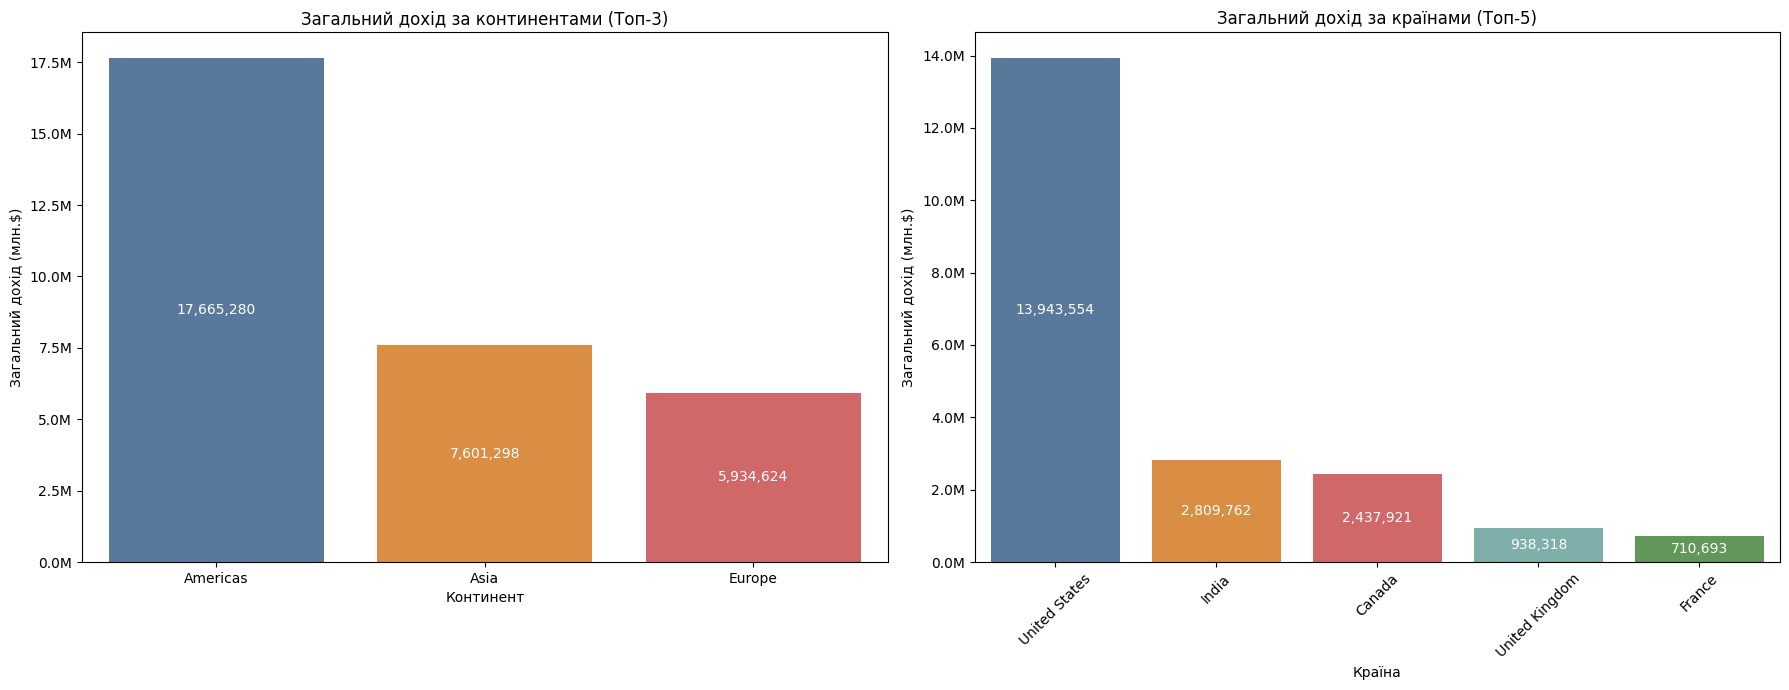

In [177]:
# Calculate total revenue by continent and identify top 3
continent_revenue = df_analysis.groupby('continent')['total_revenue'].sum().reset_index()
top_3_continents = continent_revenue.sort_values(by='total_revenue', ascending=False).head(3)

print("Топ-3 континенти за загальним доходом:")
display(top_3_continents)

# Calculate total revenue by country and identify top 5
country_revenue = df_analysis.groupby('country')['total_revenue'].sum().reset_index()
top_5_countries = country_revenue.sort_values(by='total_revenue', ascending=False).head(5)

print("\nТоп-5 країн за загальним доходом:")
display(top_5_countries)

# Create a figure with 1 row and 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot for top 3 continents
plot_bar_visualization_grid(
    df=top_3_continents,
    x_col='continent',
    y_col='total_revenue',
    title='Загальний дохід за континентами (Топ-3)',
    xlabel='Континент',
    ylabel='Загальний дохід (млн.$)',
    ax=axes[0],
    rotation=0,
    inside_bar_value=True,
    # palette='viridis'
    palette=custom_tableau_palette
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:,.1f}M'))


# Plot for top 5 countries
plot_bar_visualization_grid(
    df=top_5_countries,
    x_col='country',
    y_col='total_revenue',
    title='Загальний дохід за країнами (Топ-5)',
    xlabel='Країна',
    ylabel='Загальний дохід (млн.$)',
    ax=axes[1],
    rotation=45,
    inside_bar_value=True,
    # palette='magma'
    palette=custom_tableau_palette
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:,.1f}M'))

plt.tight_layout()
plt.show()

##### Аналіз кількості замовлень

Розрахуємо загальну кількість унікальних замовлень та візуалізуємо їх розподіл.


In [178]:
# 1. Calculate the total number of unique orders
total_unique_orders = df_analysis['session_id'].nunique()
print(f"Загальна кількість унікальних замовлень: {total_unique_orders}")

# 2. Calculate the number of items per unique order (session)
items_per_session = df_analysis['session_id'].value_counts()
print(f"Максимальна кількість унікальних товарів у замовлені: {items_per_session.max()}")



Загальна кількість унікальних замовлень: 33538
Максимальна кількість унікальних товарів у замовлені: 1


##### Визначимо ТОП - 10 категорій товарів за загальним обсягом продажів

Згрупуємо дані за `product_category` та підсумувємо `total_revenue`, щоб знайти загальний обсяг продажів для кожної категорії.
Визначимо та візуалізуємо ТОП - 10 категорій товарів за загальним обсягом продажів за допомогою стовпчастої діаграми.


ТОП - 10 категорій товарів за загальним обсягом продажів:


,product_category,total_revenue
12,Sofas & armchairs,8388254.5
5,Chairs,6147748.8
1,Beds,4919725.0
2,Bookcases & shelving units,3640818.1
3,Cabinets & cupboards,2336499.5
9,Outdoor furniture,2142222.2
13,Tables & desks,1790307.5
6,Chests of drawers & drawer units,906562.5
0,Bar furniture,735503.0
7,Children's furniture,467697.0


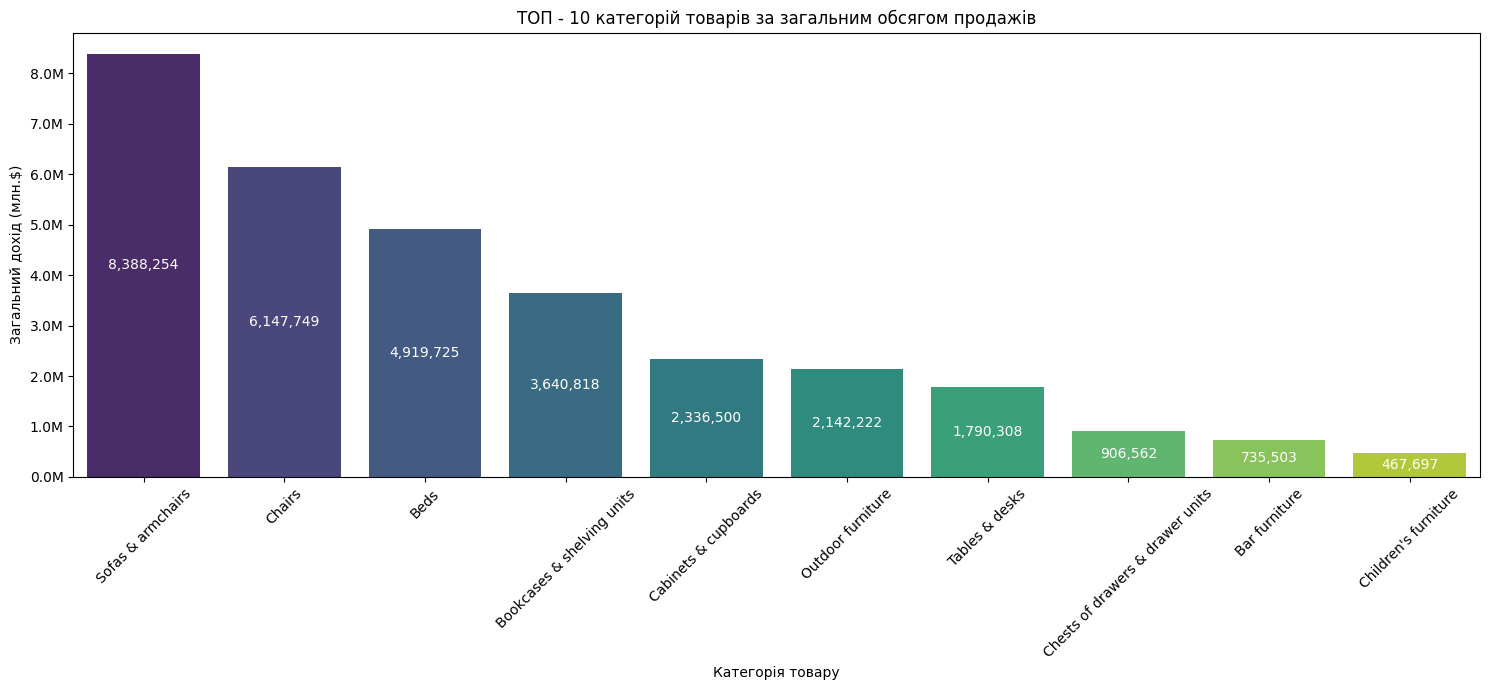

In [179]:
# 1. Group df_analysis by product_category and sum total_revenue
category_revenue = df_analysis.groupby('product_category')['total_revenue'].sum().reset_index()

# 2. Sort the result and get the top 10 categories
top_10_categories = category_revenue.sort_values(by='total_revenue', ascending=False).head(10)

print("ТОП - 10 категорій товарів за загальним обсягом продажів:")
display(top_10_categories)

# 3. Create a bar chart using the plot_bar_visualization_grid function
plt.figure(figsize=(15, 7))
ax = plt.gca() # Get current axes

plot_bar_visualization_grid(
    df=top_10_categories,
    x_col='product_category',
    y_col='total_revenue',
    title='ТОП - 10 категорій товарів за загальним обсягом продажів',
    xlabel='Категорія товару',
    ylabel='Загальний дохід (млн.$)',
    ax=ax,
    rotation=45,
    inside_bar_value=True,
    palette='viridis'
)

# 4. Format the y-axis labels to display in millions (M)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:,.1f}M'))

plt.tight_layout()
plt.show()

###### Висновок

На основі візуалізації "ТОП - 10 категорій товарів за загальним обсягом продажів" можемо зробити наступні висновки:

- **Лідери за доходом**: Категорія `Sofas & armchairs` є абсолютним лідером за загальним обсягом продажів, генеруючи найбільший дохід. За нею йдуть `Chairs` та `Beds`, які також демонструють значні обсяги продажів;
- **Різниця в масштабах**: Існує помітна різниця в обсягах продажів між першою трійкою лідерів та категоріями, що знаходяться нижче в рейтингу. Наприклад, "Sofas & armchairs" має дохід близько 8.4 млн. доларів, тоді як "Bar furniture" та "Children's furniture" мають значно менший дохід – близько 0.7-0.5 млн. доларів відповідно;
- **Розмаїття асортименту**: Топ-10 включає різноманітні категорії меблів, від великих предметів (дивани, ліжка) до менших та спеціалізованих (барні меблі, дитячі меблі).

**Загальний висновок**: Компанії слід розглянути можливість зосередитися на подальшому розвитку та маркетингу категорій `Sofas & armchairs`, `Chairs` та `Beds`, оскільки вони є основними джерелами доходу. Для категорій з меншим обсягом продажів, таких як `Bar furniture` та `Children's furniture`, можна розглянути стратегії для збільшення їхньої привабливості або переглянути цінову політику, якщо вони мають високу маржинальність.

##### Порівняння ТОП - 10 категорій товарів у країні з найбільшими продажами та загалом

Визначимо країну з найбільшим загальним обсягом продажів, потім для цієї країни знайдемо ТОП - 10 категорій товарів за загальним обсягом продажів. Порівняємо ці ТОП - 10 категорій із загальним ТОП - 10 категорій товарів та візуалізувати їх.



Висновок:
	Країна з найбільшим загальним обсягом продажів: United States

	Топ-10 категорій товарів для United States за загальним обсягом продажів:


,product_category,total_revenue
12,Sofas & armchairs,3707144.5
5,Chairs,2619773.8
1,Beds,2213058.0
2,Bookcases & shelving units,1567606.9
3,Cabinets & cupboards,994545.5
9,Outdoor furniture,929245.2
13,Tables & desks,777865.0
6,Chests of drawers & drawer units,382388.0
0,Bar furniture,330805.0
7,Children's furniture,207575.0


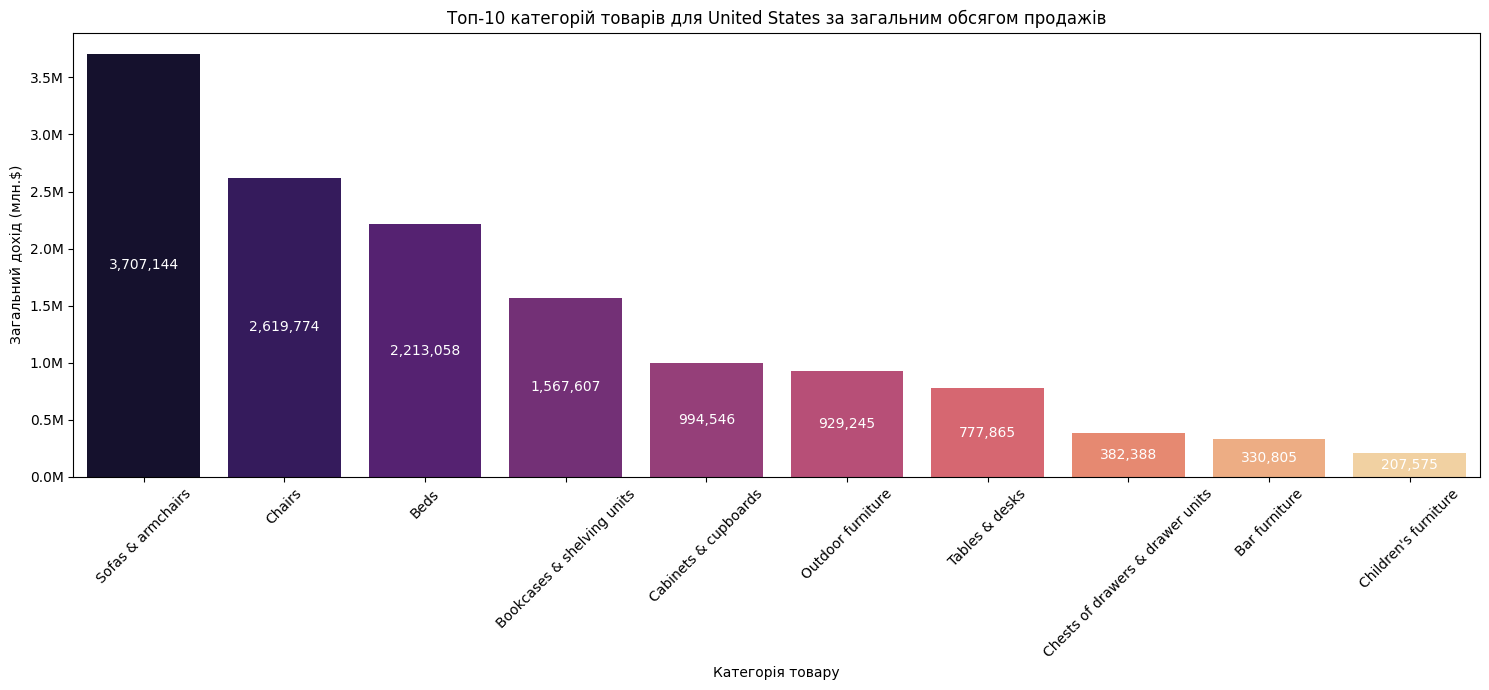

In [180]:
# 1. Identify the country with the highest total_revenue
highest_revenue_country_name = country_revenue.sort_values(by='total_revenue', ascending=False).iloc[0]['country']
print(f"\nВисновок:\n\tКраїна з найбільшим загальним обсягом продажів: {highest_revenue_country_name}")

# 2. Filter df_analysis for this country
df_country_top_sales = df_analysis[df_analysis['country'] == highest_revenue_country_name]

# 3. Group by product_category and sum total_revenue for this country
country_category_revenue = df_country_top_sales.groupby('product_category')['total_revenue'].sum().reset_index()

# 4. Get the top 10 product categories for this country
top_10_categories_country = country_category_revenue.sort_values(by='total_revenue', ascending=False).head(10)

# 5. Display the top 10 categories for the highest revenue country
print(f"\n\tТоп-10 категорій товарів для {highest_revenue_country_name} за загальним обсягом продажів:")
display(top_10_categories_country)

# 6. Create a bar chart for these top 10 categories
plt.figure(figsize=(15, 7))
ax_country = plt.gca()

plot_bar_visualization_grid(
    df=top_10_categories_country,
    x_col='product_category',
    y_col='total_revenue',
    title=f'Топ-10 категорій товарів для {highest_revenue_country_name} за загальним обсягом продажів',
    xlabel='Категорія товару',
    ylabel='Загальний дохід (млн.$)',
    ax=ax_country,
    rotation=45,
    inside_bar_value=True,
    palette='magma'
)

# Format the y-axis labels to display in millions (M)
ax_country.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:,.1f}M'))

plt.tight_layout()
plt.show()

##### Порівняння ТОП- 10 категорій товарів у країні з найбільшими продажами та загалом

На основі візуалізацій та таблиць ТОП - 10 категорій товарів за загальним обсягом продажів (як для всіх країн, так і для країни з найбільшим доходом, якою є **United States**), можна зробити наступні висновки:

###### Загальний топ-10 категорій товарів (для всіх країн):

| product_category             | total_revenue |
| :--------------------------- | ------------- |
| Sofas & armchairs            | 8388254.5     |
| Chairs                       | 6147748.8     |
| Beds                         | 4919725.0     |
| Bookcases & shelving units   | 3640818.1     |
| Cabinets & cupboards         | 2336499.5     |
| Outdoor furniture            | 2142222.2     |
| Tables & desks               | 1790307.5     |
| Chests of drawers & drawer units | 906562.5      |
| Bar furniture                | 735503.0      |
| Children's furniture         | 553075.0      |

###### Топ-10 категорій товарів для United States:

| product_category             | total_revenue |
| :--------------------------- | ------------- |
| Sofas & armchairs            | 3707144.5     |
| Chairs                       | 2619773.8     |
| Beds                         | 2213058.0     |
| Bookcases & shelving units   | 1567606.9     |
| Cabinets & cupboards         | 994545.5      |
| Outdoor furniture            | 929245.2      |
| Tables & desks               | 777865.0      |
| Chests of drawers & drawer units | 382388.0      |
| Bar furniture                | 330805.0      |
| Children's furniture         | 207575.0      |

###### Порівняльний аналіз:

1.  **Подібність у порядку лідерів**: Як у загальному топ-10, так і в топ-10 для United States, перші позиції займають ті ж самі категорії: `Sofas & armchairs`, `Chairs`, `Beds`, `Bookcases & shelving units`, `Cabinets & cupboards`, `Outdoor furniture`, `Tables & desks`. Це свідчить про те, що найбільш популярні та прибуткові категорії товарів є універсальними та користуються високим попитом як на глобальному рівні, так і на найбільшому ринку – у США.

2.  **Пропорційний внесок**: Хоча абсолютні значення доходу для кожної категорії в United States нижчі, ніж загальні, пропорційне співвідношення між категоріями залишається дуже схожим. Наприклад, `Sofas & armchairs` є лідером в обох випадках зі значним відривом від наступних категорій.

3.  **Ідентичність категорій**: Всі категорії, що входять до топ-10 для United States, також присутні в загальному топ-10. Це підкреслює домінуючу роль ринку США у формуванні загальних тенденцій продажів компанії.


###### Висновок
Ситуація з топ-10 категоріями товарів у країні з найбільшими продажами (United States) **не відрізняється суттєво** від загальної. Це вказує на те, що ринок США значною мірою відображає загальні уподобання та купівельну поведінку клієнтів компанії. Стратегії, спрямовані на просування цих ключових категорій, ймовірно, будуть ефективними як на найбільшому ринку, так і в глобальному масштабі.

##### Аналіз продажів за типами та моделями пристроїв

Згрупуємо продажі за `device` та `device_model_name` та розрахуємо відсоток загального обсягу продажів для кожної комбінації. Візуалізувати цей розподіл, наприклад, за допомогою кругових діаграм або стовпчастих діаграм з накопиченням, включно з відповідними легендами.


Продажі за браузерами та їх відсоток від загального обсягу продажів:


,browser,total_revenue,percentage
2,Chrome,21826850.0,68.269215
5,Safari,7526544.0,23.541246
0,<Other>,923354.8,2.888035
3,Edge,716444.3,2.240868
4,Firefox,567523.6,1.775079
1,Android Webview,411014.4,1.285556


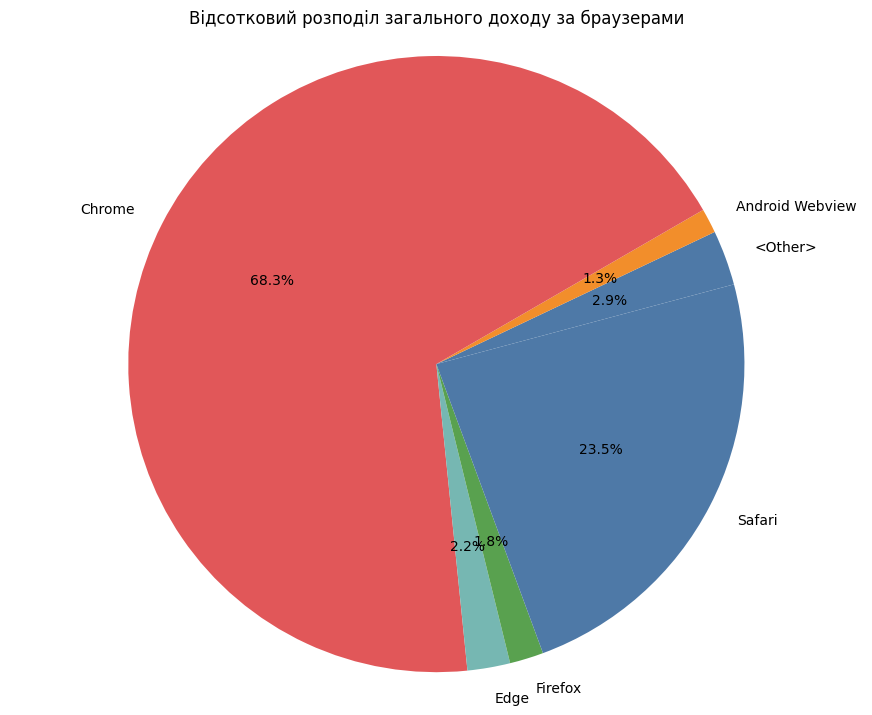

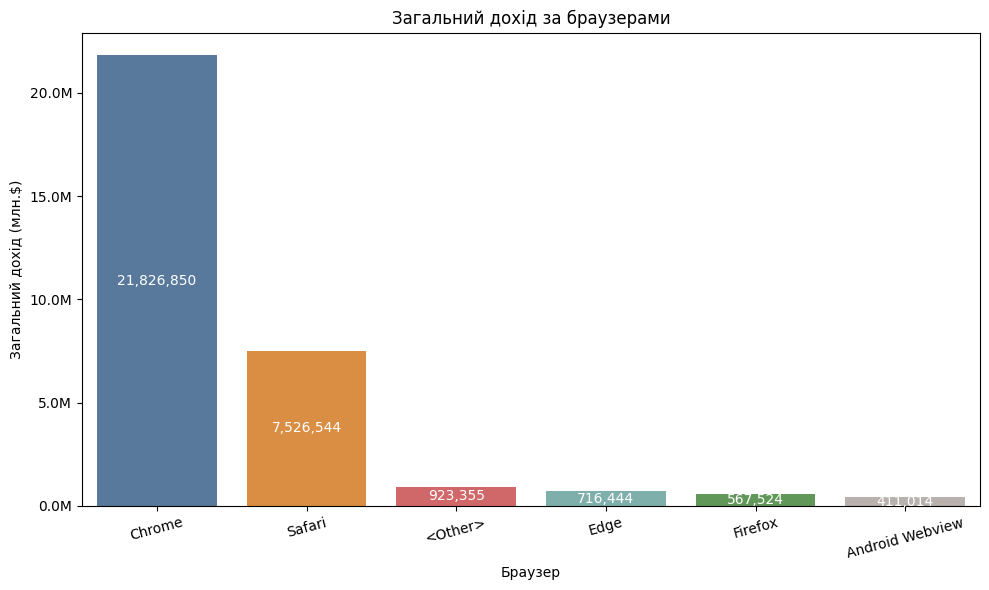


Продажі за операційними системами та їх відсоток від загального обсягу продажів:


,operating_system,total_revenue,percentage
3,Web,18445904.5,57.694419
4,Windows,3804989.0,11.901104
5,iOS,3603329.4,11.270361
1,Android,2789985.1,8.726412
2,Macintosh,2504967.3,7.834944
0,<Other>,822555.8,2.572760


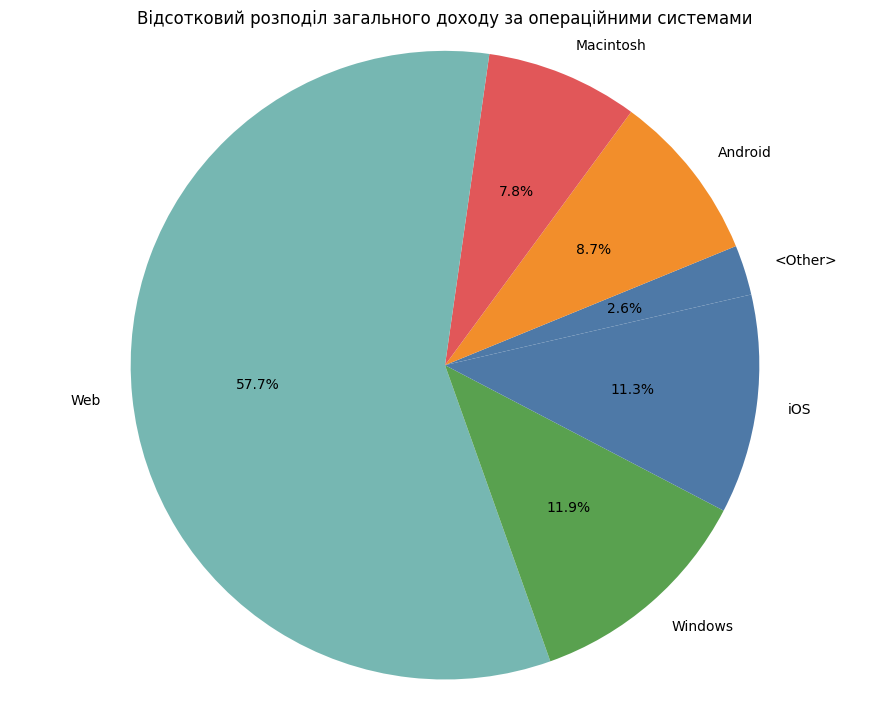

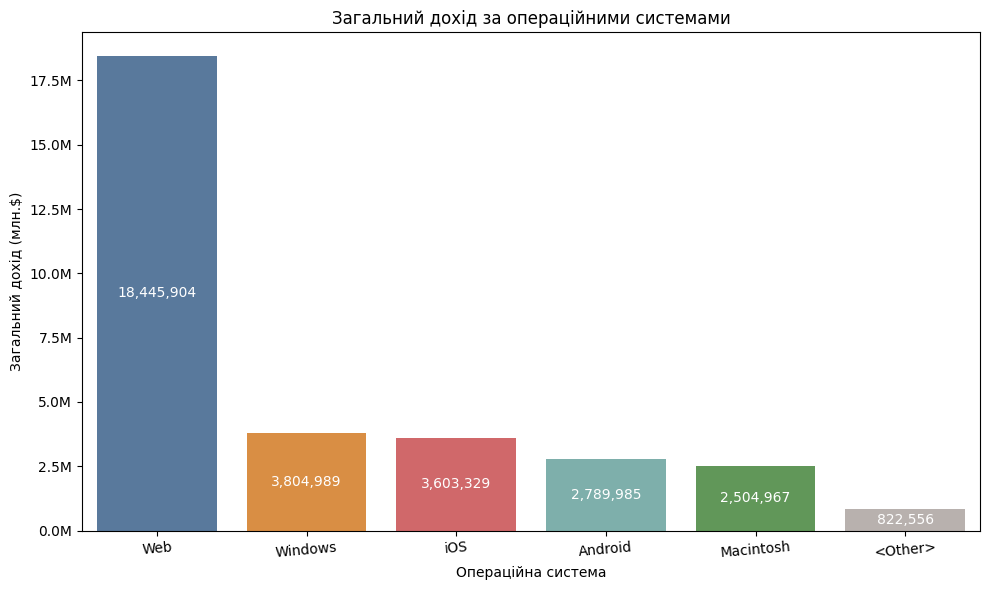

In [181]:
# --- Analyze sales by browser ---

# 1. Group df_analysis by 'browser' and calculate total revenue for each browser
browser_sales = df_analysis.groupby('browser')['total_revenue'].sum().reset_index()

# 2. Calculate the percentage of total revenue for each browser
total_overall_revenue = browser_sales['total_revenue'].sum()
browser_sales['percentage'] = (browser_sales['total_revenue'] / total_overall_revenue) * 100

print("Продажі за браузерами та їх відсоток від загального обсягу продажів:")
display(browser_sales.sort_values(by='total_revenue', ascending=False))

# 3. Create a pie chart for the percentage of total revenue by browser
plt.figure(figsize=(9, 7.2))
plt.pie(browser_sales['percentage'],
        labels=browser_sales['browser'], autopct='%1.1f%%',
        startangle=15,
        #colors=sns.color_palette('magma', len(browser_sales)))
        colors=custom_tableau_palette[:len(browser_sales)]) #

plt.title('Відсотковий розподіл загального доходу за браузерами')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

# 3a. Create a bar chart for browser sales using plot_bar_visualization_grid
plt.figure(figsize=(10, 6))
ax_browser_bar = plt.gca()
plot_bar_visualization_grid(
    df=browser_sales.sort_values(by='total_revenue', ascending=False),
    x_col='browser',
    y_col='total_revenue',
    title='Загальний дохід за браузерами',
    xlabel='Браузер',
    ylabel='Загальний дохід (млн.$)',
    ax=ax_browser_bar,
    rotation=15,
    inside_bar_value=True,
    # palette='viridis'
    palette=custom_tableau_palette_sns
)
ax_browser_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:,.1f}M'))
plt.tight_layout()
plt.show()

# --- Analyze sales by operating system ---

# 4. Group df_analysis by 'operating_system' and calculate total revenue for each operating system
os_sales = df_analysis.groupby('operating_system')['total_revenue'].sum().reset_index()

# 5. Calculate the percentage of total revenue for each operating system
total_overall_revenue = os_sales['total_revenue'].sum()
os_sales['percentage'] = (os_sales['total_revenue'] / total_overall_revenue) * 100

print("\nПродажі за операційними системами та їх відсоток від загального обсягу продажів:")
display(os_sales.sort_values(by='total_revenue', ascending=False))

# 6. Create a pie chart for the percentage of total revenue by operating system
plt.figure(figsize=(9, 7.2))
plt.pie(os_sales['percentage'],
        labels=os_sales['operating_system'], autopct='%1.1f%%',
        startangle=13,
        colors=custom_tableau_palette[:len(os_sales)]) # Use custom_tableau_palette here

plt.title('Відсотковий розподіл загального доходу за операційними системами')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

# 6a. Create a bar chart for OS sales using plot_bar_visualization_grid
plt.figure(figsize=(10, 6))
ax_os_bar = plt.gca()
plot_bar_visualization_grid(
    df=os_sales.sort_values(by='total_revenue', ascending=False),
    x_col='operating_system',
    y_col='total_revenue',
    title='Загальний дохід за операційними системами',
    xlabel='Операційна система',
    ylabel='Загальний дохід (млн.$)',
    ax=ax_os_bar,
    rotation=5,
    inside_bar_value=True,
    # palette='magma'
    custom_palette=custom_tableau_palette_sns# Use custom_palette here
)
ax_os_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:,.1f}M'))
plt.tight_layout()
plt.show()

###### Висновки

`Продажі за браузерами:`

- `Chrome` є найбільш домінуючим браузером, на нього припадає приблизно 68.3% від загального доходу;

- `Safari` посідає друге місце, приносячи близько 23.5% від загального доходу;

- `Інші браузери`, такі як Edge, Firefox, Android Webview та , вносять значно менші відсотки, від 1.3% до 2.9%.

`Продажі за операційними системами:`
- `Web` (ймовірно, представляє браузерні системи або невідомі ОС) є провідною операційною системою, на яку припадає близько 57.7% від загального доходу;

- `Windows` та `iOS` йдуть слідом, кожна з них вносить приблизно 11.9% та 11.3% відповідно;

- `Android` та `Macintosh` також мають помітні частки, близько 8.7% та 7.8% доходу;

- інші, невизначені операційні системи складають меншу частину, близько 2.6%.

Ці дані підкреслюють важливість оптимізації вебприсутності та маркетингових кампаній для користувачів `Chrome/Safari та Web/Windows/iOS`.

##### Аналіз продажів за джерелами трафіку

Згрупуємо продажі за `traffic_source_info` та `traffic_channel` та розрахувати відсоток загального обсягу продажів для кожного. Візуалізувати цей розподіл, наприклад, за допомогою кругових діаграм або стовпчастих діаграм з накопиченням, включно з відповідними легендами.


Продажі за джерелами трафіку та їх відсоток від загального обсягу продажів:


,traffic_source_info,total_revenue,percentage
4,organic,10935239.9,34.202840
1,(none),7494923.4,23.442345
5,referral,5641855.2,17.646386
2,<Other>,4491351.1,14.047882
0,(data deleted),2041921.0,6.386645
3,cpc,1366440.5,4.273902


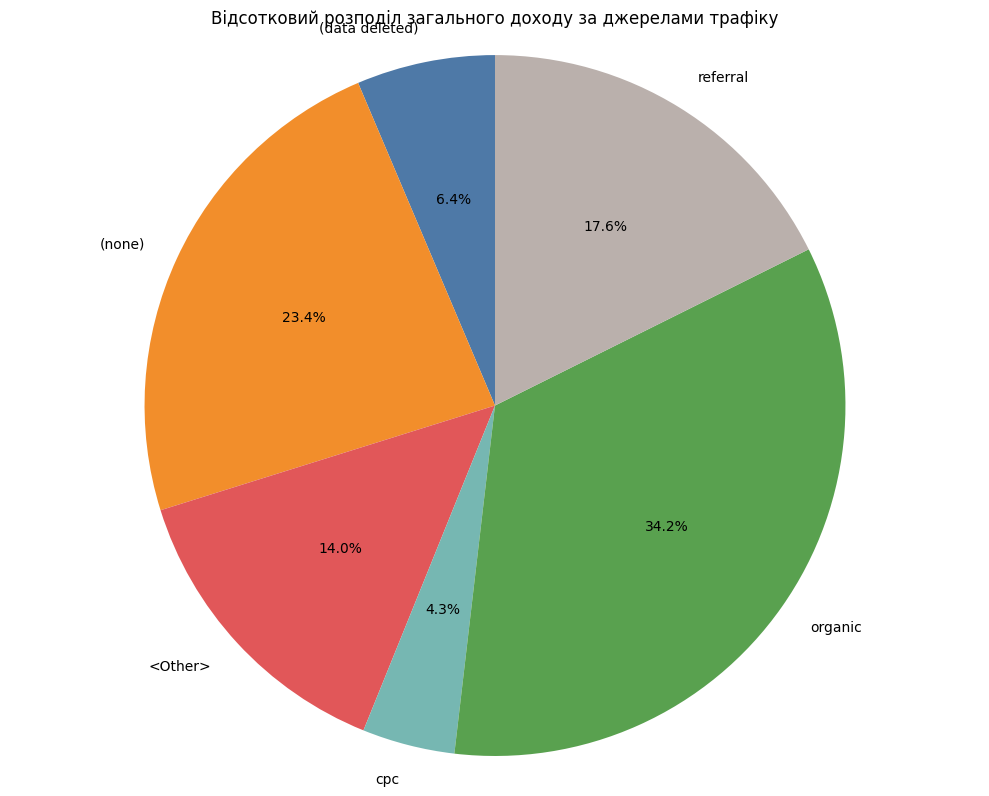

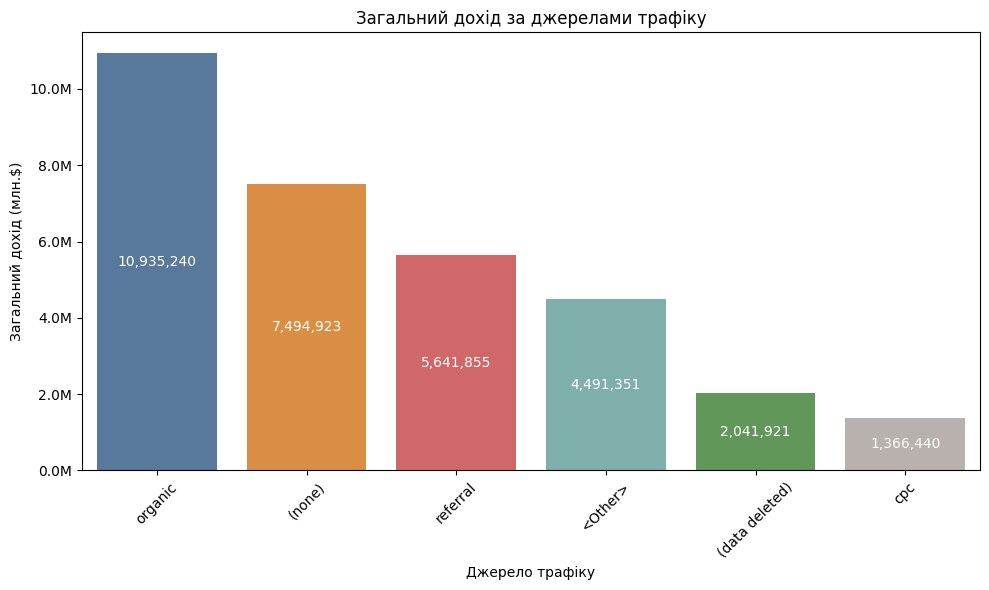


Продажі за каналами трафіку та їх відсоток від загального обсягу продажів:


,traffic_channel,total_revenue,percentage
1,Organic Search,11433151.6,35.760189
2,Paid Search,8511049.4,26.620546
0,Direct,7494923.4,23.442345
3,Social Search,2532105.7,7.919827
4,Undefined,2000501.0,6.257093


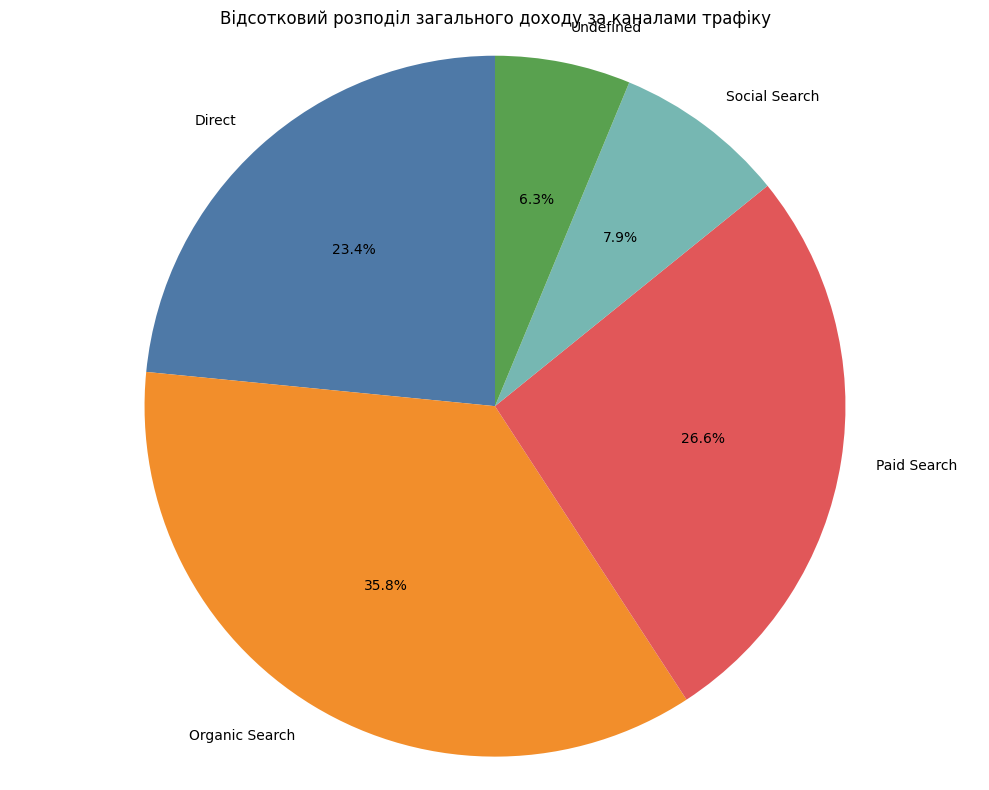

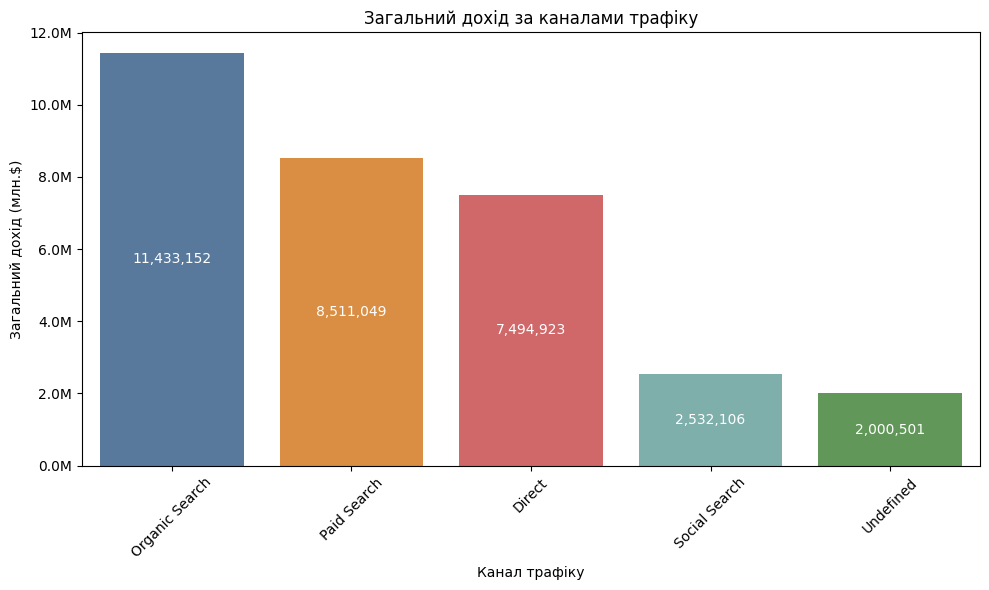

In [182]:
# 1. Group df_analysis by 'traffic_source_info' and calculate total revenue for each traffic source
traffic_source_sales = df_analysis.groupby('traffic_source_info')['total_revenue'].sum().reset_index()

# 2. Calculate the percentage of total revenue for each traffic source
total_overall_revenue = traffic_source_sales['total_revenue'].sum()
traffic_source_sales['percentage'] = (traffic_source_sales['total_revenue'] / total_overall_revenue) * 100

print("Продажі за джерелами трафіку та їх відсоток від загального обсягу продажів:")
display(traffic_source_sales.sort_values(by='total_revenue', ascending=False))

# 3. Create a pie chart for the percentage of total revenue by traffic source
plt.figure(figsize=(10, 8))
plt.pie(traffic_source_sales['percentage'],
        labels=traffic_source_sales['traffic_source_info'], autopct='%1.1f%%', startangle=90, colors=custom_tableau_palette_sns[:len(traffic_source_sales)]) # Use custom_tableau_palette here
plt.title('Відсотковий розподіл загального доходу за джерелами трафіку')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

# 3a. Create a bar chart for traffic source sales using plot_bar_visualization_grid
plt.figure(figsize=(10, 6))
ax_traffic_source_bar = plt.gca()
plot_bar_visualization_grid(
    df=traffic_source_sales.sort_values(by='total_revenue', ascending=False),
    x_col='traffic_source_info',
    y_col='total_revenue',
    title='Загальний дохід за джерелами трафіку',
    xlabel='Джерело трафіку',
    ylabel='Загальний дохід (млн.$)',
    ax=ax_traffic_source_bar,
    rotation=45,
    inside_bar_value=True,
    # palette='viridis'
    custom_palette=custom_tableau_palette_sns # Use custom_palette here
)
ax_traffic_source_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:,.1f}M'))
plt.tight_layout()
plt.show()

# 4. Group df_analysis by 'traffic_channel' and calculate total revenue for each traffic channel
traffic_channel_sales = df_analysis.groupby('traffic_channel')['total_revenue'].sum().reset_index()

# 5. Calculate the percentage of total revenue for each traffic channel
total_overall_revenue = traffic_channel_sales['total_revenue'].sum()
traffic_channel_sales['percentage'] = (traffic_channel_sales['total_revenue'] / total_overall_revenue) * 100

print("\nПродажі за каналами трафіку та їх відсоток від загального обсягу продажів:")
display(traffic_channel_sales.sort_values(by='total_revenue', ascending=False))

# 6. Create a pie chart for the percentage of total revenue by traffic channel
plt.figure(figsize=(10, 8))
plt.pie(traffic_channel_sales['percentage'],
        labels=traffic_channel_sales['traffic_channel'], autopct='%1.1f%%', startangle=90,
        # colors=sns.color_palette('magma', len(traffic_channel_sales)))
        colors=custom_tableau_palette_sns[:len(traffic_channel_sales)]) # Use custom_tableau_palette here
plt.title('Відсотковий розподіл загального доходу за каналами трафіку')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

# 6a. Create a bar chart for traffic channel sales using plot_bar_visualization_grid
plt.figure(figsize=(10, 6))
ax_traffic_channel_bar = plt.gca()
plot_bar_visualization_grid(
    df=traffic_channel_sales.sort_values(by='total_revenue', ascending=False),
    x_col='traffic_channel',
    y_col='total_revenue',
    title='Загальний дохід за каналами трафіку',
    xlabel='Канал трафіку',
    ylabel='Загальний дохід (млн.$)',
    ax=ax_traffic_channel_bar,
    rotation=45,
    inside_bar_value=True,
    # palette='magma'
    custom_palette=custom_tableau_palette # Use custom_palette here
)
ax_traffic_channel_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:,.1f}M'))
plt.tight_layout()
plt.show()

###### Висновок

**Продажі за джерелами трафіку **(Traffic Source Info):

- `Organic` є найважливішим джерелом, що приносить 34.2% від загального доходу;
- `(none)` (ймовірно, прямий трафік) посідає друге місце з 23.4% доходу;
- `Referral` та також є значними джерелами, вносячи 17.6% та 14.0% відповідно;
- `(data deleted)` та cpc (платний трафік) мають меншу частку, близько 6.4% та 4.3% відповідно.

**Продажі за каналами трафіку **(Traffic Channel):
- `Organic Search` є провідним каналом, відповідальним за 35.8% загального доходу;
- `Paid Search` та `Direct` також є значними каналами, приносячи 26.6% та 23.4% доходу відповідно;
- `Social Search` та `Undefined` мають меншу частку, близько 7.9% та 6.3% відповідно.

Ці дані підкреслюють важливість `Organic` та `Direct` трафіку, а також `Organic Search`, `Paid Search` та `Direct` каналів для генерації доходу. Ця аналітика може бути варта уваги маркетологів у частині допомоги в оптимізації маркетингових стратегій та розподілу бюджетів на різні джерела та канали.

##### Розрахунок відсотка підтвердження електронної пошти

Розрахуємо відсоток зареєстрованих користувачів, які підтвердили свою електронну адресу.


In [183]:
registered_users_df = df_analysis[df_analysis['registered_user_id'] != 0]

total_registered_users = registered_users_df['registered_user_id'].nunique()
verified_registered_users = registered_users_df[registered_users_df['is_verified'] == True]['registered_user_id'].nunique()

percentage_verified = (verified_registered_users / total_registered_users) * 100

print(f"Висновок:\n\tВідсоток зареєстрованих користувачів, які підтвердили свою електронну адресу: {percentage_verified:.2f}%")

Висновок:
	Відсоток зареєстрованих користувачів, які підтвердили свою електронну адресу: 71.52%


##### Розрахунок відсотка відписки від розсилки

Розрахуємо відсоток зареєстрованих користувачів, які відписалися від розсилки.


In [184]:
registered_users_df = df_analysis[df_analysis['registered_user_id'] != 0]

total_registered_users = registered_users_df['registered_user_id'].nunique()
unsubscribed_registered_users = registered_users_df[registered_users_df['is_unsubscribed'] == True]['registered_user_id'].nunique()

percentage_unsubscribed = (unsubscribed_registered_users / total_registered_users) * 100

print(f"Висновок:\n\tВідсоток зареєстрованих користувачів, які відписалися від розсилки: {percentage_unsubscribed:.2f}%")

Висновок:
	Відсоток зареєстрованих користувачів, які відписалися від розсилки: 16.07%


##### Порівняння поведінки продажів: користувачі, що відписалися, та підписані користувачі

Порівняємо загальний обсяг продажів (`total_revenue`) користувачів, які `is_unsubscribed = True`, з користувачами, які `is_unsubscribed = False` (серед зареєстрованих користувачів).

Загальний дохід зареєстрованих користувачів за статусом підписки:


,is_unsubscribed,total_revenue
0,False,2150796.9
1,True,431721.6


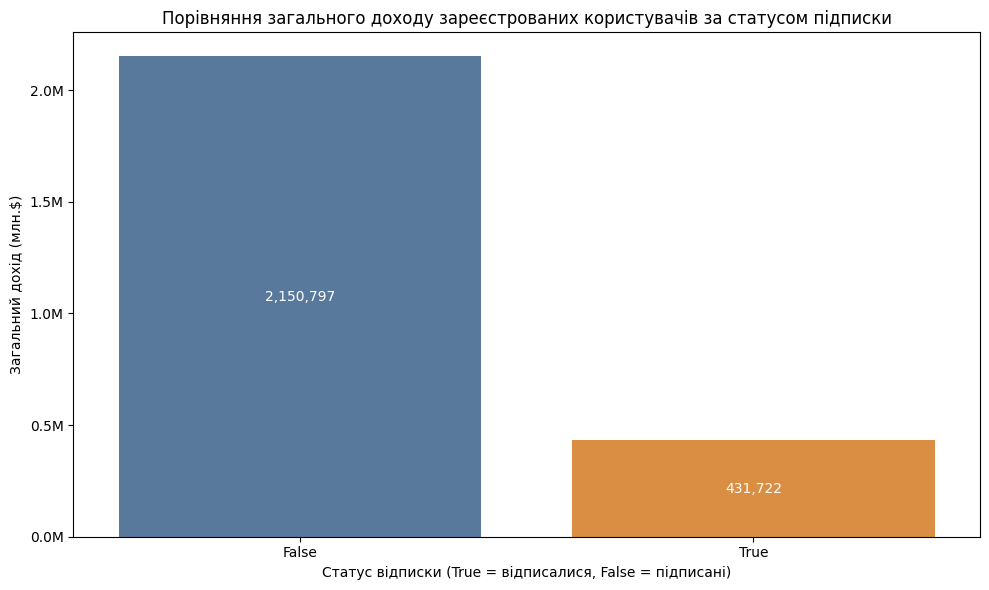

In [185]:
# 1. Filter df_analysis for registered users (where registered_user_id is not 0)
registered_users_df = df_analysis[df_analysis['registered_user_id'] != 0]

# 2. Group the filtered DataFrame by 'is_unsubscribed' and calculate the sum of 'total_revenue'
unsubscribed_revenue = registered_users_df.groupby('is_unsubscribed')['total_revenue'].sum().reset_index()

print("Загальний дохід зареєстрованих користувачів за статусом підписки:")
display(unsubscribed_revenue)

# 3. Create a bar chart for visualizing total_revenue for each group (is_unsubscribed)
plt.figure(figsize=(10, 6))
ax = plt.gca()

plot_bar_visualization_grid(
    df=unsubscribed_revenue,
    x_col='is_unsubscribed',
    y_col='total_revenue',
    title='Порівняння загального доходу зареєстрованих користувачів за статусом підписки',
    xlabel='Статус відписки (True = відписалися, False = підписані)',
    ylabel='Загальний дохід (млн.$)',
    ax=ax,
    rotation=0,
    inside_bar_value=True,
    # palette='viridis'
    palette=custom_tableau_palette[:2]
)

# 6. Format the y-axis labels to display in millions (M)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:,.1f}M'))

plt.tight_layout()
plt.show()

###### Висновок

На основі стовпчастої діаграми, що порівнює загальний дохід зареєстрованих користувачів за статусом підписки (`is_unsubscribed`), можна зробити наступні висновки:

-   **Значна різниця в доходах**: Користувачі, які *не відписалися* від розсилки (`False`), генерують значно вищий загальний дохід (приблизно 2.15 млн.$) порівняно з користувачами, які *відписалися* (`True`) (приблизно 0.43 млн.$);

-   **Прибутковість підписаних користувачів**: Користувачі, які продовжують отримувати розсилку, є набагато ціннішими для компанії з точки зору доходу. Їхній сукупний дохід приблизно в 5 разів перевищує дохід від тих, хто відписався.

-   **Можливі причини**:
    -   **Зацікавленість**: Користувачі, які залишаються підписаними, ймовірно, більш зацікавлені в продуктах або пропозиціях компанії, що призводить до частіших або більших покупок.
    -   **Інформація**: Розсилка може інформувати їх про нові продукти, акції та знижки, що стимулює продажі.
    -   **Лояльність**: Можливо, підписані користувачі є більш лояльними клієнтами.

### Висновок:
Існує чітка різниця в поведінці продажів між зареєстрованими користувачами залежно від їхнього статусу підписки. Користувачі, які не відписалися від розсилки, є значно більш прибутковими. Це підкреслює важливість утримання підписників та ефективності маркетингових розсилок для генерації доходу. Компанії варто інвестувати в стратегії, спрямовані на підвищення зацікавленості підписників та зменшення кількості відписок(*бажано провести додаткове дослідження причин скасування підписки*), оскільки це безпосередньо впливає на її фінансові показники.

##### Визначення країн з найбільшою кількістю зареєстрованих користувачів

Згрупуємо дані за `country` та підрахувати кількість унікальних `registered_user_id` (де `registered_user_id` > 0) у кожній країні. Визначимо та візуалізуємо топ-країни з найбільшою кількістю зареєстрованих користувачів.


Топ-країни з найбільшою кількістю зареєстрованих користувачів:


,country,registered_user_id
83,United States,1207
32,India,246
14,Canada,207
82,United Kingdom,88
25,France,56
27,Germany,56
76,Taiwan,51
72,Spain,48
16,China,48
68,Singapore,44


/tmp/ipython-input-1623260456.py:42: UserWarning: 
The palette list has fewer values (5) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=x_col, y=y_col, data=df, ax=ax, order=order, color=color, hue=x_col, legend=False, palette=final_palette, estimator=sum, errorbar=None)


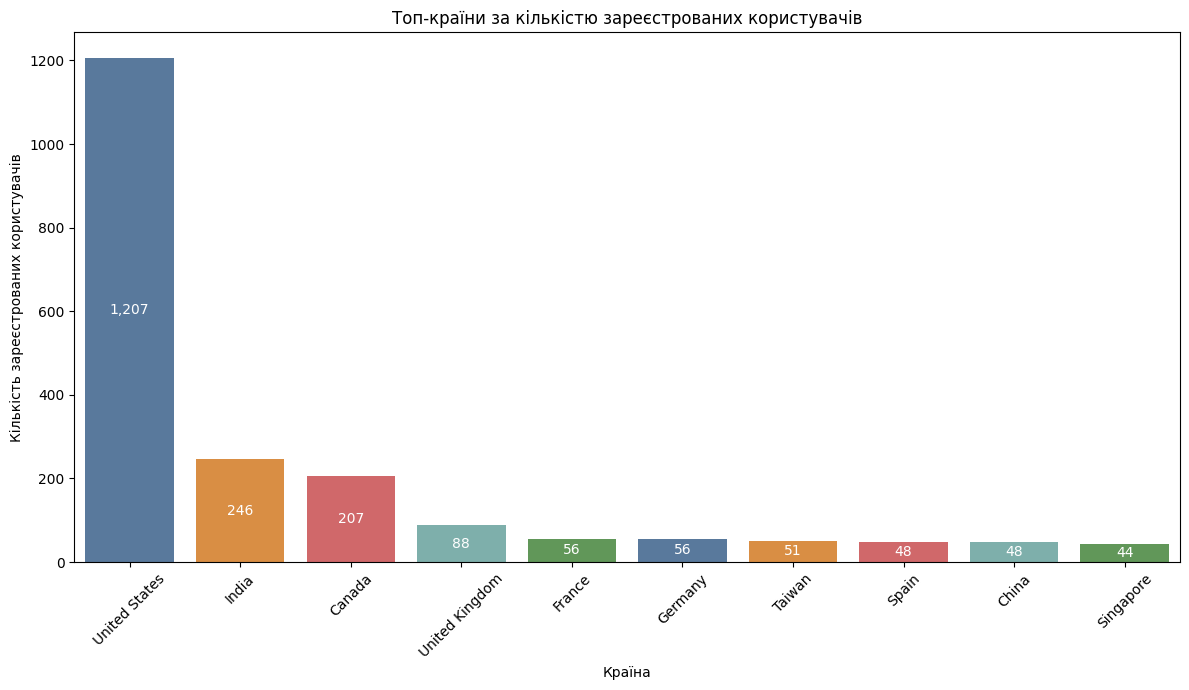

In [186]:
# 1. Filter df_analysis for registered users (where registered_user_id is not 0)
registered_users_only_df = df_analysis[df_analysis['registered_user_id'] != 0]

# 2. Group by 'country' and count unique 'registered_user_id'
registered_users_by_country = registered_users_only_df.groupby('country')['registered_user_id'].nunique().reset_index()

# 3. Sort by count of registered users in descending order and select top countries (e.g., top 10)
top_countries_by_registered_users = registered_users_by_country.sort_values(by='registered_user_id', ascending=False).head(10)

print("Топ-країни з найбільшою кількістю зареєстрованих користувачів:")
display(top_countries_by_registered_users)

# 4. Create a bar chart for visualizing top countries by registered users
plt.figure(figsize=(12, 7))
ax = plt.gca() # Get current axes

plot_bar_visualization_grid(
    df=top_countries_by_registered_users,
    x_col='country',
    y_col='registered_user_id',
    title='Топ-країни за кількістю зареєстрованих користувачів',
    xlabel='Країна',
    ylabel='Кількість зареєстрованих користувачів',
    ax=ax,
    rotation=45,
    inside_bar_value=True,
    # palette='viridis'
    custom_palette=custom_tableau_palette # Use custom_palette here
)

plt.tight_layout()
plt.show()

##### Аналіз продажів за браузером та операційною системою.

Проаналізуємо продажі за браузером та операційною системою.


Продажі за браузерами та їх відсоток від загального обсягу продажів:


,browser,total_revenue,percentage
2,Chrome,21826850.0,68.269215
5,Safari,7526544.0,23.541246
0,<Other>,923354.8,2.888035
3,Edge,716444.3,2.240868
4,Firefox,567523.6,1.775079
1,Android Webview,411014.4,1.285556


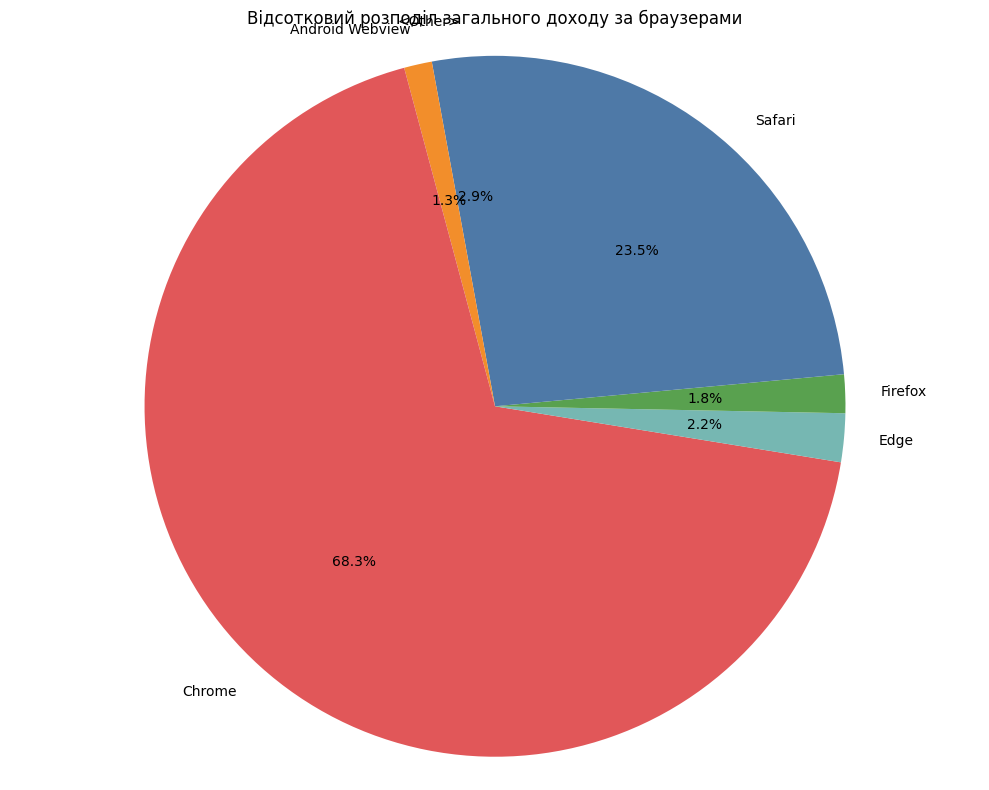


Продажі за операційними системами та їх відсоток від загального обсягу продажів:


,operating_system,total_revenue,percentage
3,Web,18445904.5,57.694419
4,Windows,3804989.0,11.901104
5,iOS,3603329.4,11.270361
1,Android,2789985.1,8.726412
2,Macintosh,2504967.3,7.834944
0,<Other>,822555.8,2.572760


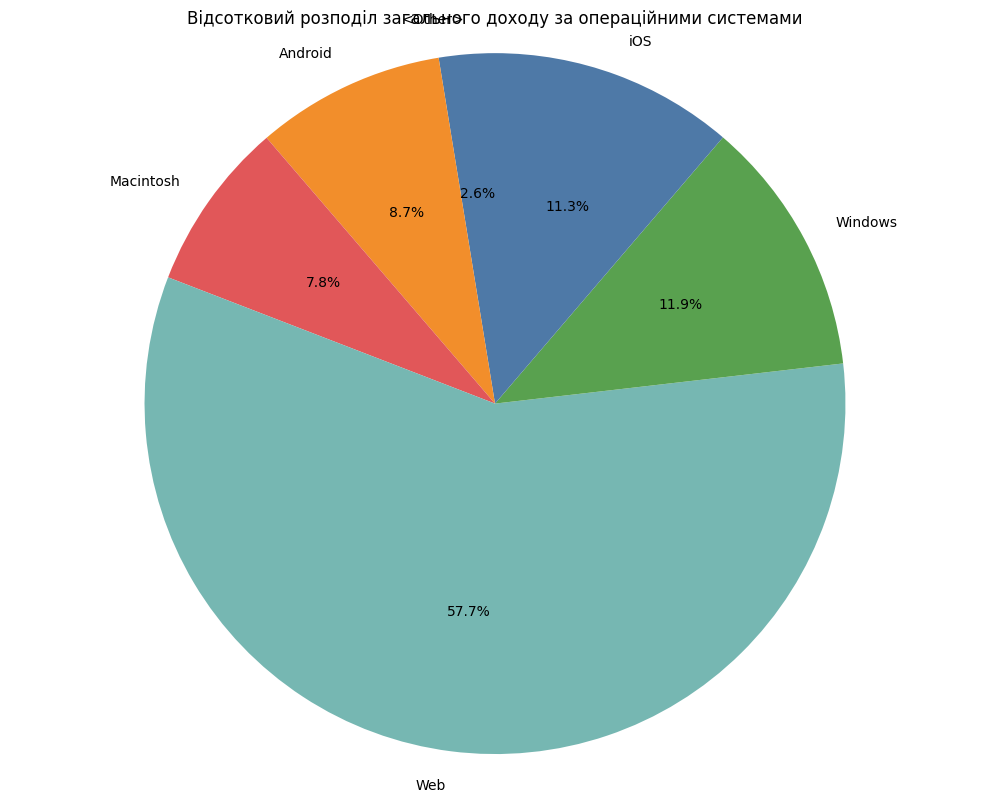

In [187]:
# --- Analyze sales by browser ---

# 1. Group df_analysis by 'browser' and calculate total revenue for each browser
browser_sales = df_analysis.groupby('browser')['total_revenue'].sum().reset_index()

# 2. Calculate the percentage of total revenue for each browser
total_overall_revenue = browser_sales['total_revenue'].sum()
browser_sales['percentage'] = (browser_sales['total_revenue'] / total_overall_revenue) * 100

print("Продажі за браузерами та їх відсоток від загального обсягу продажів:")
display(browser_sales.sort_values(by='total_revenue', ascending=False))

# 3. Create a pie chart for the percentage of total revenue by browser
plt.figure(figsize=(10, 8))
plt.pie(browser_sales['percentage'],
        labels=browser_sales['browser'], autopct='%1.1f%%', startangle=90,
        # colors=sns.color_palette('viridis', len(browser_sales)))
        colors=sns.color_palette(custom_tableau_palette, len(browser_sales)))
plt.title('Відсотковий розподіл загального доходу за браузерами')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

# --- Analyze sales by operating system ---

# 4. Group df_analysis by 'operating_system' and calculate total revenue for each operating system
os_sales = df_analysis.groupby('operating_system')['total_revenue'].sum().reset_index()

# 5. Calculate the percentage of total revenue for each operating system
total_overall_revenue = os_sales['total_revenue'].sum()
os_sales['percentage'] = (os_sales['total_revenue'] / total_overall_revenue) * 100

print("\nПродажі за операційними системами та їх відсоток від загального обсягу продажів:")
display(os_sales.sort_values(by='total_revenue', ascending=False))

# 6. Create a pie chart for the percentage of total revenue by operating system
plt.figure(figsize=(10, 8))
plt.pie(os_sales['percentage'],
        labels=os_sales['operating_system'], autopct='%1.1f%%', startangle=90,
        # colors=sns.color_palette('magma', len(os_sales)))
        colors=sns.color_palette(custom_tableau_palette, len(os_sales)))
plt.title('Відсотковий розподіл загального доходу за операційними системами')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()


Продажі за операційними системами, згруповані за типом пристрою:


device,desktop,mobile,tablet
operating_system,,,
<Other>,820999.8,1331.0,225.0
Android,0.0,2649766.5,140218.6
Macintosh,2504967.3,0.0,0.0
Web,11737871.9,6326020.6,382012.0
Windows,3800200.0,0.0,4789.0
iOS,0.0,3407107.7,196221.7


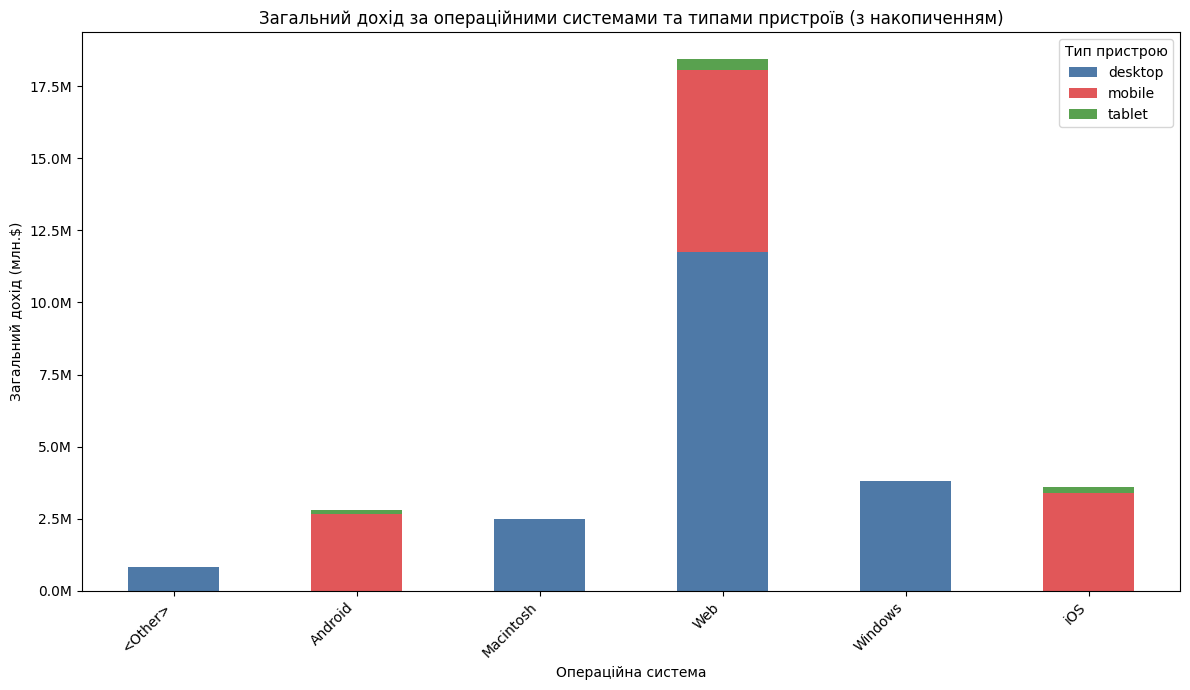

In [188]:
import matplotlib.colors

# 1. Group df_analysis by 'operating_system' and 'device', then sum 'total_revenue'
os_device_sales = df_analysis.groupby(['operating_system', 'device'])['total_revenue'].sum().unstack(fill_value=0)

print("Продажі за операційними системами, згруповані за типом пристрою:")
display(os_device_sales)

# Create a colormap from the custom_tableau_palette
custom_cmap = matplotlib.colors.ListedColormap(custom_tableau_palette)

# 2. Plotting the stacked bar chart
plt.figure(figsize=(12, 7))
# ax = os_device_sales.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')
ax = os_device_sales.plot(kind='bar', stacked=True, ax=plt.gca(), cmap=custom_cmap) # Use the custom colormap
plt.title('Загальний дохід за операційними системами та типами пристроїв (з накопиченням)')
plt.xlabel('Операційна система')
plt.ylabel('Загальний дохід (млн.$)')
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:,.1f}M'))
plt.legend(title='Тип пристрою')
plt.tight_layout()
plt.show()

###### Висновок

Продажі за операційними системами, згруповані за типом пристрою:
- `Web` є лідером за загальним доходом, значна частина якого припадає як на
  - `desktop` (11,737,871.9);
  - `mobile` (6,326,020.6).

Це свідчить про широке використання веб-інтерфейсів для доступу;

- `Windows` (3,800,200.0 на desktop) та `iOS` (3,407,107.7 на mobile) є значними джерелами доходу, що підкреслює їхню популярність.
- `Android` (2,649,766.5 на mobile) та Macintosh (2,504,967.3 на desktop) також роблять суттєвий внесок.

Операційні системи генерують дохід переважно з desktop пристроїв.

**Загальний висновок**:

Web-орієнтовані продажі: Домінування Web у поєднанні з desktop та mobile пристроями вказує на критичну важливість веб-присутності та її оптимізації для всіх типів пристроїв.

Різноманітність платформ: Значні продажі через Windows, iOS, Android та Macintosh підтверджують необхідність забезпечення сумісності та якісного досвіду користувача на різних операційних системах.

`Desktop vs Mobile`: Хоча desktop є основним джерелом доходу для деяких ОС (наприклад, Windows, Macintosh), mobile пристрої відіграють ключову роль для інших (наприклад, iOS, Android).

##### Аналіз продажів за браузером (з накопиченням за типом пристрою)

Продажі за браузерами, згруповані за типом пристрою:


device,desktop,mobile,tablet
browser,,,
<Other>,318000.9,544545.3,60808.6
Android Webview,0.0,392386.4,18628.0
Chrome,15778375.2,5667208.9,381265.9
Edge,716444.3,0.0,0.0
Firefox,535659.6,31864.0,0.0
Safari,1515559.0,5748221.2,262763.8


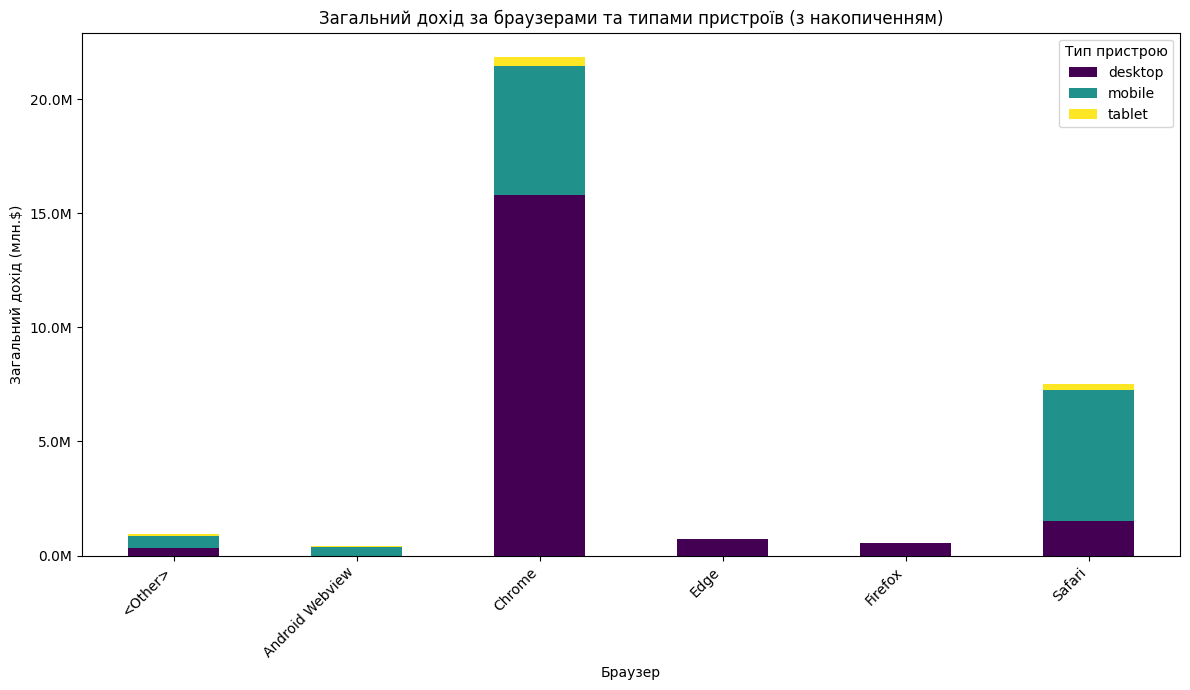

In [189]:
# 1. Group df_analysis by 'browser' and 'device', then sum 'total_revenue'
browser_device_sales = df_analysis.groupby(['browser', 'device'])['total_revenue'].sum().unstack(fill_value=0)

print("Продажі за браузерами, згруповані за типом пристрою:")
display(browser_device_sales)

# 2. Plotting the stacked bar chart
plt.figure(figsize=(12, 7))
ax = browser_device_sales.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')
plt.title('Загальний дохід за браузерами та типами пристроїв (з накопиченням)')
plt.xlabel('Браузер')
plt.ylabel('Загальний дохід (млн.$)')
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:,.1f}M'))
plt.legend(title='Тип пристрою')
plt.tight_layout()
plt.show()

###### Висновок

Продажі за браузерами, згруповані за типом пристрою:

- `Chrome` є лідером за загальним доходом, значна частина якого припадає на `desktop` пристрої (`15,778,375.2`). Продажі через `mobile` (`5,667,208.9`) та `tablet` (`381,265.9`) також є суттєвими;

- `Safari` посідає друге місце, причому дохід від `mobile` пристроїв (`5,748,221.2`) дещо перевищує дохід від `desktop` (`1,515,559.0`). Це свідчить про міцні позиції Safari на мобільних платформах.
Інші браузери, такі як Edge та Firefox, генерують дохід переважно з desktop пристроїв;

- `Android Webview` показує значний дохід з `mobile ` пристроїв (3`92,386.4`), що є очікуваним.
категорія також демонструє значний дохід від `mobile` пристроїв (`544,545.3`).

**Загальний висновок**:

- `Desktop-орієнтовані продажі`: Chrome на десктопі є абсолютним лідером, що підкреслює важливість оптимізації веб-сайту для цієї комбінації;

- `Мобільний ринок`: Safari на мобільних пристроях є дуже сильним гравцем, що свідчить про значний потенціал мобільного маркетингу для користувачів iOS;

**Різноманітність платформ**: Хоча домінують Chrome і Safari, присутність інших браузерів і пристроїв вказує на необхідність підтримки крос-браузерної та крос-платформної сумісності.

##### Віконні функції
— це потужний інструмент SQL, який дозволяє виконувати обчислення над набором рядків, пов’язаних із поточним рядком. Вони дуже корисні для аналітичних завдань, які потребують агрегації даних без згортання результатів, зберігаючи при цьому всі деталі.

Чи доречно їх використовувати в поточному SQL-запиті?

На даному етапі, коли ми зосереджені на об'єднанні таблиць, виборі колонок та базовій імпутації (COALESCE), віконні функції не є прямо необхідними.

Однак, вони будуть дуже доречними та корисними на наступних етапах аналізу даних, особливо якщо ми захочемо:

Ранжувати дані: Наприклад, визначити ранг продукту за обсягом продажів в певній категорії або країні (ROW_NUMBER(), RANK(), DENSE_RANK()).
Обчислювати рухомі середні або кумулятивні суми: Наприклад, розрахувати кумулятивний дохід користувача або рухоме середнє продажів за останні N днів (SUM() OVER, AVG() OVER).
Порівнювати поточні значення з попередніми/наступними: Наприклад, визначити час між послідовними замовленнями користувача (LAG(), LEAD()).
Обчислювати відсоток від загального: Наприклад, частка продажів продукту від загального обсягу продажів категорії (SUM(price) OVER () / SUM(price) OVER (PARTITION BY category)).
Висновок: Для поточної задачі (створення агрегованого датасету з імпутацією) віконні функції не потрібні. Але для майбутнього розвідувального та статистичного аналізу вони будуть незамінними для отримання глибинних інсайтів.

##### Візуалізація ТОП-10 товарів за доходом у категорії `Sofas & armchairs`

In [190]:
query = """
SELECT
    p.category AS product_category,
    p.name AS product_name,
    SUM(p.price) AS total_revenue,
    RANK() OVER (PARTITION BY p.category ORDER BY SUM(p.price) DESC) AS product_rank_in_category
FROM
    `data-analytics-mate.DA.order` AS o
JOIN
    `data-analytics-mate.DA.product` AS p ON o.item_id = p.item_id
GROUP BY
    p.category,
    p.name
ORDER BY
    product_category,
    product_rank_in_category
"""

try:
    query_job = client.query(query)
    ranked_products_df = query_job.to_dataframe()

    print("Перші 10 рядків DataFrame з ранжованими продуктами:")
    display(ranked_products_df.head(10))

except Exception as e:
    print(f"Помилка при виконанні запиту: {e}")
    print("Будь ласка, перевірте дозволи для вашого облікового запису Google на доступ до таблиць BigQuery в проекті 'data-analytics-mate'.")


Перші 10 рядків DataFrame з ранжованими продуктами:


,product_category,product_name,total_revenue,product_rank_in_category
0,Bar furniture,EKEDALEN / EKEDALEN,199647.0,1
1,Bar furniture,NORRÅKER / NORRÅKER,120442.0,2
2,Bar furniture,NORRÅKER / NORRARYD,60973.0,3
3,Bar furniture,EKEDALEN,53562.0,4
4,Bar furniture,JANINGE,35105.0,5
5,Bar furniture,HENRIKSDAL,34205.0,6
6,Bar furniture,NORDVIKEN,20910.0,7
7,Bar furniture,NORRÅKER,20185.0,8
8,Bar furniture,STENSELE / NORRARYD,20100.0,9
9,Bar furniture,STENSELE,19800.0,10


##### Створимо візуалізацію ТОП - 10 відранжованих продуктів у категорії `Sofas & armchairs`



/tmp/ipython-input-94738199.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-94738199.py:12: UserWarning: 
The palette list has fewer values (5) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


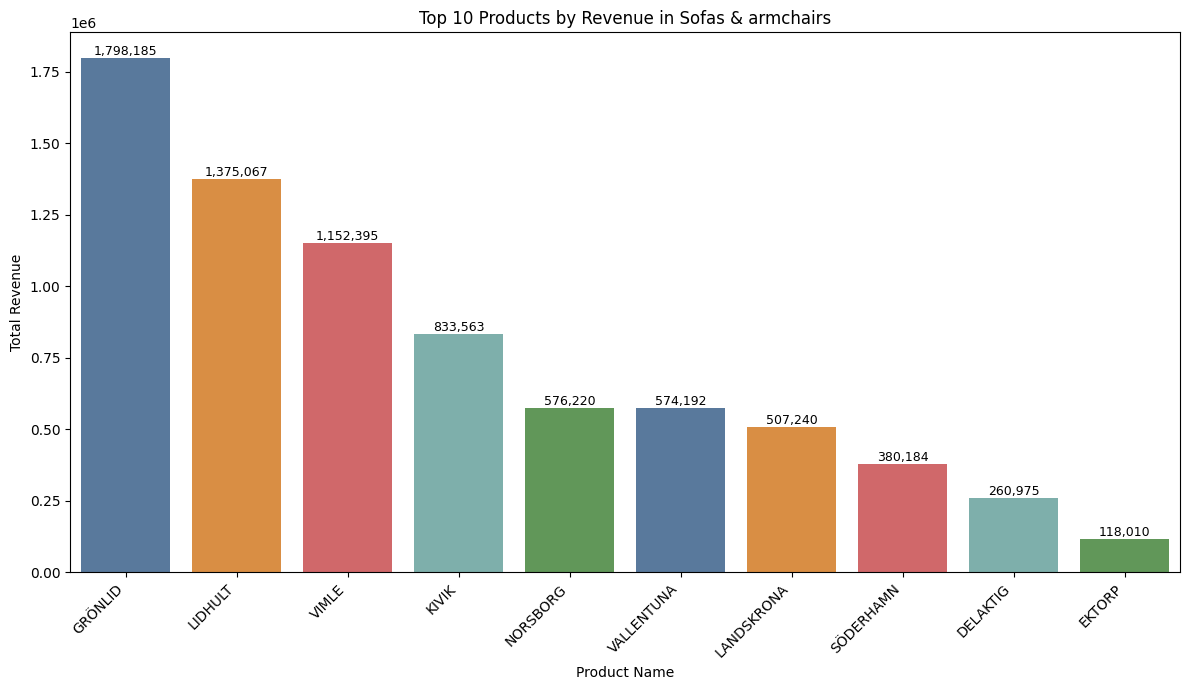

In [191]:
# 1. Choose a specific product_category to visualize
selected_category = 'Sofas & armchairs'

# 2. Filter the ranked_products_df for the chosen category
filtered_category_df = ranked_products_df[ranked_products_df['product_category'] == selected_category]

# Sort by total_revenue for better visualization and select top 10
filtered_category_df = filtered_category_df.sort_values(by='total_revenue', ascending=False).head(10)

# 3. Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(
    x='product_name',
    y='total_revenue',
    data=filtered_category_df,
    # palette='viridis'
    palette=custom_tableau_palette, # Use custom_tableau_palette
)

# 4. Set the title of the plot
plt.title(f'Top 10 Products by Revenue in {selected_category}')

# 5. Label the x-axis as 'Product Name' and the y-axis as 'Total Revenue'
plt.xlabel('Product Name')
plt.ylabel('Total Revenue')

# 6. Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add data labels on top of the bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='{:,.0f}', label_type='edge', color='black', fontsize=9)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# 7. Display the plot
plt.show()

##### SQL Query for Cumulative Revenue

Створимо SQL-запит, який обчислює загальний щоденний дохід, а потім обчислює сукупний щоденний дохід з плином часу за допомогою віконної функції.

In [192]:
query = """
WITH revenue_by_day AS (
    SELECT
        DATE(s.date) AS order_date,
        SUM(p.price) AS daily_revenue
    FROM
        `data-analytics-mate.DA.order` AS o
    JOIN
        `data-analytics-mate.DA.product` AS p ON o.item_id = p.item_id
    JOIN
        `data-analytics-mate.DA.session` AS s ON o.ga_session_id = s.ga_session_id
    GROUP BY
        DATE(s.date)
)
SELECT
    order_date,
    daily_revenue,
    SUM(daily_revenue) OVER (ORDER BY order_date) AS cumulative_daily_revenue
FROM
    revenue_by_day
ORDER BY
    order_date
"""

try:
    query_job = client.query(query)
    cumulative_revenue_df = query_job.to_dataframe()

    print("Перші кілька рядків DataFrame з кумулятивним доходом:")
    display(cumulative_revenue_df.head())

except Exception as e:
    print(f"Помилка при виконанні запиту: {e}")
    print("Будь ласка, перевірте дозволи для вашого облікового запису Google на доступ до таблиць BigQuery в проекті 'data-analytics-mate'.")

Перші кілька рядків DataFrame з кумулятивним доходом:


,order_date,daily_revenue,cumulative_daily_revenue
0,2020-11-01,244292.5,244292.5
1,2020-11-02,355506.8,599799.3
2,2020-11-03,498979.6,1098778.9
3,2020-11-04,339187.1,1437966.0
4,2020-11-05,391276.6,1829242.6


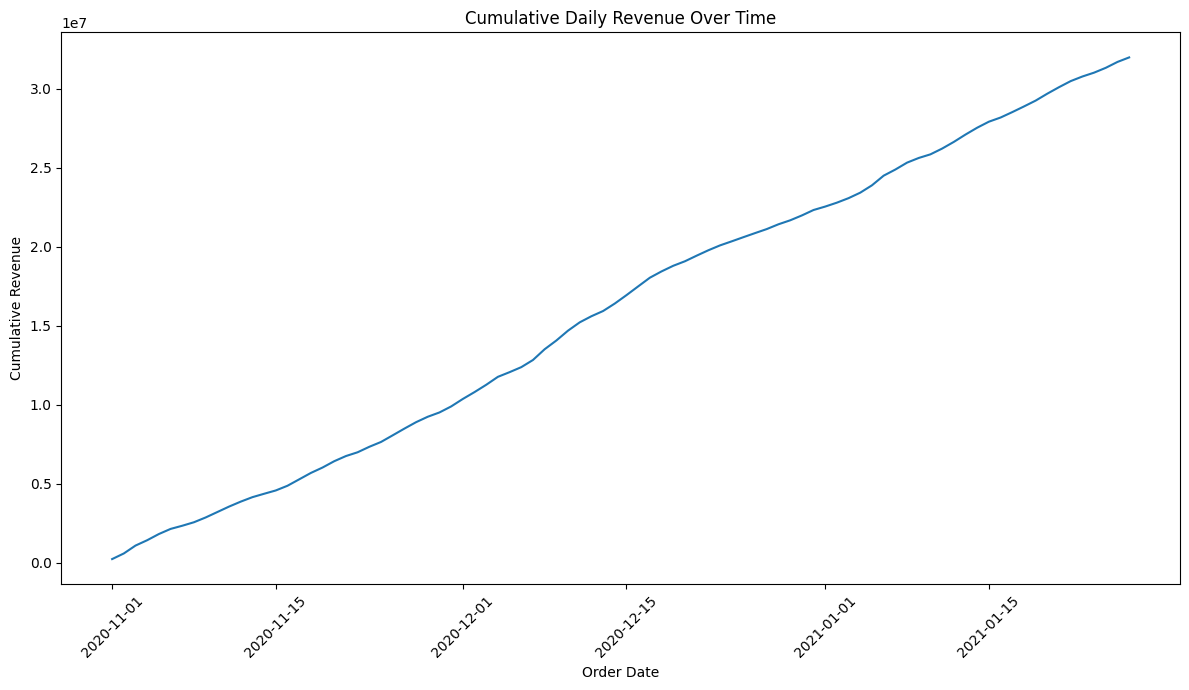

In [193]:
# 1. Create a line plot
plt.figure(figsize=(12, 7))
sns.lineplot(x='order_date', y='cumulative_daily_revenue', data=cumulative_revenue_df)

# 2. Set the title of the plot
plt.title('Cumulative Daily Revenue Over Time')

# 3. Label the x-axis as 'Order Date' and the y-axis as 'Cumulative Revenue'
plt.xlabel('Order Date')
plt.ylabel('Cumulative Revenue')

# 4. Rotate the x-axis labels by 45 degrees for better readability
plt.xticks(rotation=45)

# 5. Adjust the layout to prevent labels from overlapping
plt.tight_layout()

# 6. Display the plot
plt.show()

##### Основні висновки аналізу даних

- **Ефективність продукту за категоріями**:

Продукти були успішно ранжовані в межах своїх категорій на основі загального доходу.
Наприклад, у категорії «Меблі для бару» продукт «EKEDALEN / EKEDALEN» було визначено як продукт з найвищим рейтингом із загальним доходом у 199 647 доларів США.

- **Візуалізація доходу за категоріями**:

Гістограма ефективно візуалізувала загальний дохід для окремих продуктів у вибраній категорії, наприклад, «Дивани та крісла», що дозволило чітко порівняти ефективність товарів у цій групі.

- **Загальна тенденція зростання доходу**:

Аналіз сукупного щоденного доходу виявив безперервну висхідну тенденцію з часом, починаючи з початкового щоденного доходу в 7 994 долари США 2020-11-01, що вказує на **стабільне зростання бізнесу**.

- **Відстеження доходу за часовими рядами**:

Лінійний графік чітко проілюстрував прогресивне збільшення сукупного щоденного доходу, демонструючи загальну траєкторію фінансового зростання за спостережуваний період.


###### Аналітика або наступні кроки

Поєднання рейтингу на рівні продукту та загального відстеження сукупного доходу забезпечує надійну основу для визначення високопродуктивних продуктів та моніторингу фінансового стану бізнесу.

Подальший аналіз може включати вивчення конкретних факторів, що сприяють успіху продуктів з найвищим рейтингом у своїх категоріях, а також дослідження періодів значного зростання або стагнації в тенденції сукупного доходу для виявлення дієвих бізнес-чинників.

#### Висновки

На основі візуалізації "Топ-10 категорій товарів за загальним обсягом продажів" можна зробити наступні висновки:

- **Лідери за доходом**: Категорія `Sofas & armchairs` є абсолютним лідером за загальним обсягом продажів, генеруючи найбільший дохід. За нею йдуть `Chairs` та `Beds`, які також демонструють значні обсяги продажів.
- **Різниця в масштабах**: Існує помітна різниця в обсягах продажів між першою трійкою лідерів та категоріями, що знаходяться нижче в рейтингу. Наприклад, "Sofas & armchairs" має дохід близько 8.4 млн. доларів, тоді як "Bar furniture" та "Children's furniture" мають значно менший дохід – близько 0.7-0.5 млн. доларів відповідно.
- **Розмаїття асортименту**: Топ-10 включає різноманітні категорії меблів, від великих предметів (дивани, ліжка) до менших та спеціалізованих (барні меблі, дитячі меблі).

**Загальний висновок**: Компанії слід зосередитися на подальшому розвитку та маркетингу категорій `Sofas & armchairs`, `Chairs` та `Beds`, оскільки вони є основними джерелами доходу. Для категорій з меншим обсягом продажів, таких як `Bar furniture` та `Children's furniture`, можна розглянути стратегії для збільшення їхньої привабливості або переглянути цінову політику, якщо вони мають високу маржинальність.

### 7._Статистичний аналіз взаємозв’язків.

1. Знайдемо кількість сесій та загальні продажі за кожну дату. Створимо візуалізацію, щоб побачити взаємозв’язок між цими метриками. З'ясуємо чи корелюють ці показники?
Знайдемо відповідний коефіцієнт кореляції та проаналізуємо його статистичну значущість.
2. З'ясуємо чи корелюють між собою продажі на різних континентах? Візьмемо топ-3 континенти. Проаналізуємо статистичну значущість взаємозв’язків.
3. З'ясуємо чи корелюють між собою продажі за різними каналами трафіку? Проаналізуємо статистичну значущість взаємозв’язків.
4. З'ясуємо чи корелюють між собою продажі за топ-5 категоріями товарів? Проаналізуємо статистичну значущість взаємозв’язків.


##### 7.1. Дані про щоденні сесії та продажі

Згрупуємо `df_analysis` за `order_date`, щоб обчислити кількість унікальних `session_id` (сесій) та суму `total_revenue` (продажів) для кожної дати. Це підготує дані для аналізу зв'язку між щоденними сесіями та продажами.

In [194]:
daily_metrics_df = df_analysis.groupby('order_date').agg(
    sessions=('session_id', 'nunique'),
    sales=('total_revenue', 'sum')
).reset_index()

print("Daily metrics (sessions and sales) per date:")
display(daily_metrics_df.head())


Daily metrics (sessions and sales) per date:


,order_date,sessions,sales
0,2020-11-01,281,244292.5
1,2020-11-02,368,355506.8
2,2020-11-03,561,498979.6
3,2020-11-04,370,339187.1
4,2020-11-05,388,391276.6


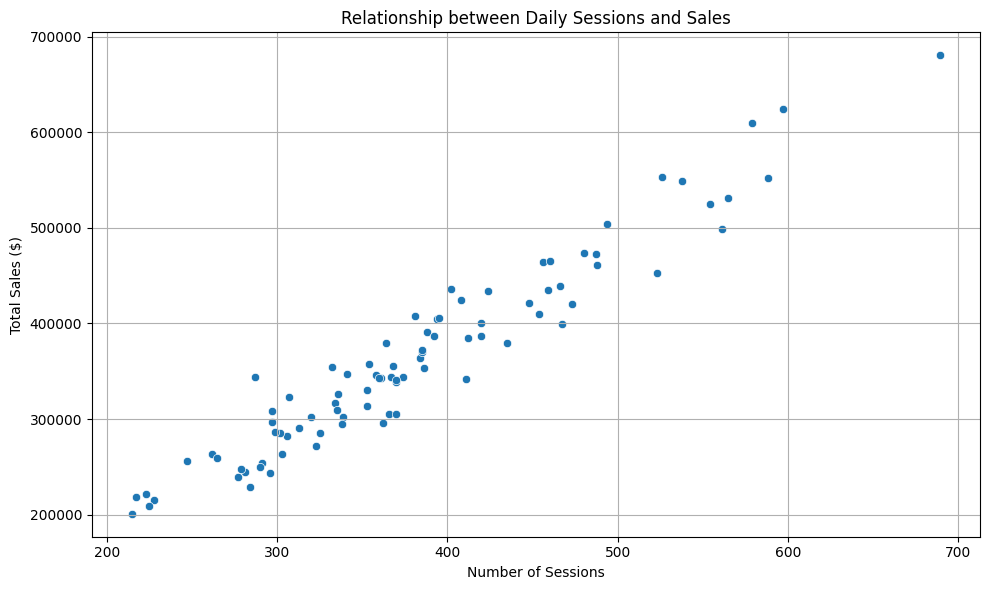

In [195]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sessions', y='sales', data=daily_metrics_df)
plt.title('Relationship between Daily Sessions and Sales')
plt.xlabel('Number of Sessions')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [196]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(daily_metrics_df['sessions'], daily_metrics_df['sales'])

print(f"Pearson Correlation Coefficient: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion:\n\tThe correlation is statistically significant (p < 0.05).")
else:
    print("Conclusion:\n\tThe correlation is not statistically significant (p >= 0.05).")

if correlation > 0:
    print("Conclusion:\n\tThere is a positive correlation between daily sessions and sales.")
elif correlation < 0:
    print("Conclusion:\n\tThere is a negative correlation between daily sessions and sales.")
else:
    print("Conclusion:\n\tThere is no linear correlation between daily sessions and sales.")

Pearson Correlation Coefficient: 0.9642
P-value: 0.0000
Conclusion:
	The correlation is statistically significant (p < 0.05).
Conclusion:
	There is a positive correlation between daily sessions and sales.


###### Висновок

**Щоденні сесії та продажі**: Існує дуже сильна позитивна та статистично значуща кореляція між кількістю щоденних сесій та загальним щоденним обсягом продажів (коефіцієнт кореляції Пірсона: 0.9642, p-значення: 0.0000). Це вказує на те, що більший трафік веб-сайту безпосередньо призводить до збільшення продажів.

##### 7.2. Дані щодо продажів на ТОП - 3 континентах

Визначимо 3 провідні континенти за допомогою `total_revenue`. Відфільтруємо `df_analysis`, щоб включити лише ці континенти. Потім перемістимо дані, щоб континенти були стовпцями, а `total_revenue` – значеннями, індексованими за `order_date`. Будь-які значення `NaN` замінимо значеннями 0.


In [197]:
continent_revenue = df_analysis.groupby('continent')['total_revenue'].sum().reset_index()
top_3_continents_names = continent_revenue.sort_values(by='total_revenue', ascending=False).head(3)['continent'].tolist()

top_3_continents_df = df_analysis[df_analysis['continent'].isin(top_3_continents_names)]

pivoted_continents_sales = top_3_continents_df.pivot_table(
    index='order_date',
    columns='continent',
    values='total_revenue',
    aggfunc='sum'
).fillna(0)

print("Pivoted sales data for the top 3 continents:")
display(pivoted_continents_sales.head())

Pivoted sales data for the top 3 continents:


continent,Americas,Asia,Europe
order_date,,,
2020-11-01,132002.5,63823.0,46908.0
2020-11-02,193861.0,79370.0,75710.8
2020-11-03,294529.8,126737.8,67692.0
2020-11-04,200009.5,66602.0,65915.0
2020-11-05,182988.2,117608.4,86540.0


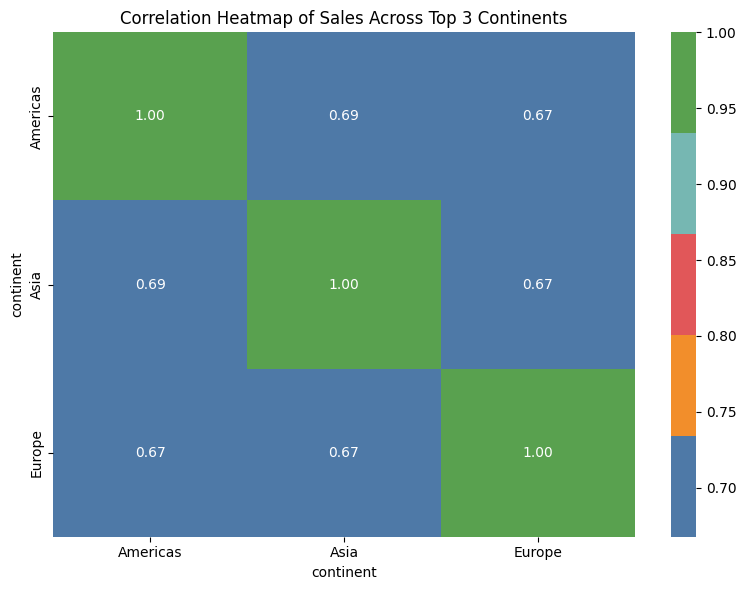

In [198]:
plt.figure(figsize=(8, 6))
sns.heatmap(pivoted_continents_sales.corr(numeric_only=True),
            annot=True,
            cmap=custom_tableau_palette,
            fmt='.2f')
plt.title('Correlation Heatmap of Sales Across Top 3 Continents')
plt.tight_layout()
plt.show()

In [199]:
from scipy.stats import pearsonr

continents = pivoted_continents_sales.columns
correlation_results = []

for i in range(len(continents)):
    for j in range(i + 1, len(continents)):
        continent1 = continents[i]
        continent2 = continents[j]

        corr, p_value = pearsonr(pivoted_continents_sales[continent1], pivoted_continents_sales[continent2])
        correlation_results.append({
            'Continent Pair': f'{continent1} vs {continent2}',
            'Pearson Correlation': f'{corr:.4f}',
            'P-value': f'{p_value:.4f}',
            'Statistically Significant (p < 0.05)': p_value < 0.05
        })

correlation_df = pd.DataFrame(correlation_results)
print("Correlation and p-values for sales across top 3 continents:")
display(correlation_df)


Correlation and p-values for sales across top 3 continents:


,Continent Pair,Pearson Correlation,P-value,Statistically Significant (p < 0.05)
0,Americas vs Asia,0.6923,0.0000,True
1,Americas vs Europe,0.6695,0.0000,True
2,Asia vs Europe,0.6678,0.0000,True


###### Висновок

**Продажі на трьох провідних континентах**: Три провідні континенти за загальним доходом — це Північна та Південна Америка, Азія та Європа. Усі пари цих континентів демонструють сильні позитивні та статистично значущі кореляції у своїх щоденних продажах:
- Північна та Південна Америка проти Азії: 0.6923 (p-значення: 0.0000);
- Північна та Південна Америка проти Європи: 0.6695 (p-значення: 0.0000);
- Азія проти Європи: 0.6678 (p-значення: 0.0000) Це свідчить про те, що тенденції продажів у цих основних регіонах, як правило, рухаються в тандемі.

##### 7.3. Дані про продажі за каналами трафіку

Згрупуємо `df_analysis` за `order_date` та `traffic_channel`. Згрупуємо дані, щоб `traffic_channel` були стовпцями, а `total_revenue` значеннями, індексованими за `order_date`. Заповнимо будь-які значення `NaN` значеннями 0.


In [200]:
traffic_channel_sales_pivot = df_analysis.groupby(['order_date', 'traffic_channel'])['total_revenue'].sum().unstack(fill_value=0)

print("Pivoted sales data by traffic channel, indexed by date:")
display(traffic_channel_sales_pivot.head())

Pivoted sales data by traffic channel, indexed by date:


traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
order_date,,,,,
2020-11-01,54669.5,95112.0,64688.0,25078.0,4745.0
2020-11-02,81561.5,127746.5,104780.8,16843.0,24575.0
2020-11-03,102909.5,182521.9,152641.3,27652.5,33254.4
2020-11-04,79683.6,117067.1,100332.0,24257.4,17847.0
2020-11-05,83367.6,122938.4,107648.0,41693.2,35629.4


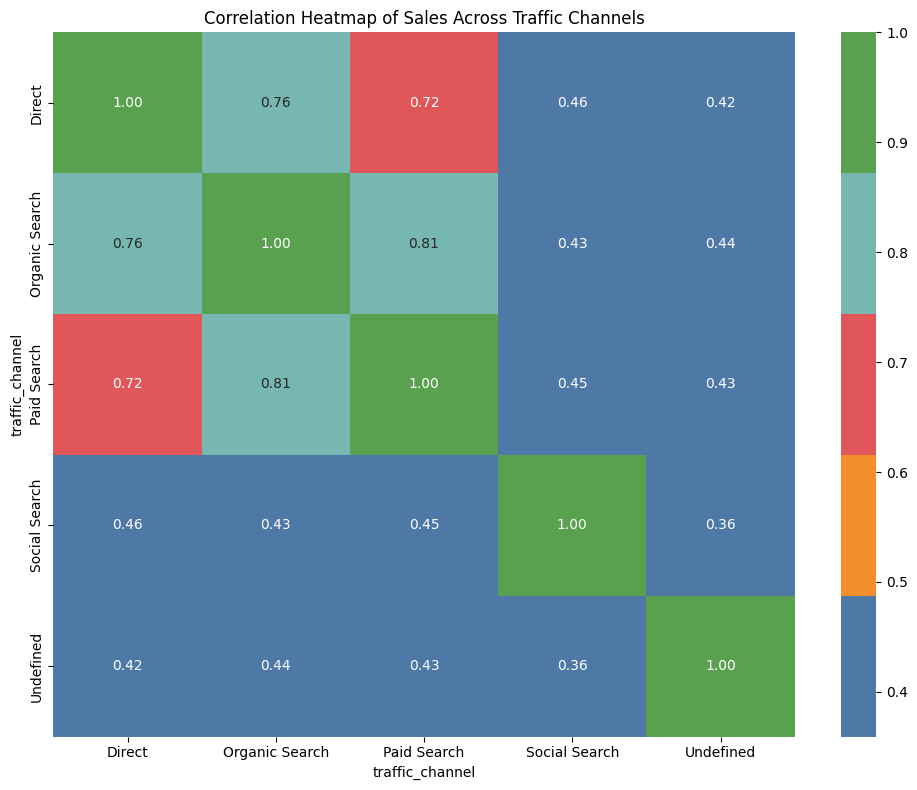

In [201]:
plt.figure(figsize=(10, 8))
sns.heatmap(traffic_channel_sales_pivot.corr(numeric_only=True),
            annot=True,
            cmap=custom_tableau_palette,
            fmt='.2f')
plt.title('Correlation Heatmap of Sales Across Traffic Channels')
plt.tight_layout()
plt.show()

In [202]:
from scipy.stats import pearsonr

traffic_channels = traffic_channel_sales_pivot.columns
correlation_results_channels = []

for i in range(len(traffic_channels)):
    for j in range(i + 1, len(traffic_channels)):
        channel1 = traffic_channels[i]
        channel2 = traffic_channels[j]

        corr, p_value = pearsonr(traffic_channel_sales_pivot[channel1], traffic_channel_sales_pivot[channel2])

        correlation_results_channels.append({
            'Traffic Channel Pair': f'{channel1} vs {channel2}',
            'Pearson Correlation': f'{corr:.6f}',
            'P-value': f'{p_value:.6f}',
            'Statistically Significant (p < 0.05)': p_value < 0.05
        })

correlation_df_channels = pd.DataFrame(correlation_results_channels)
print("Correlation and p-values for sales across traffic channels:")
display(correlation_df_channels)

Correlation and p-values for sales across traffic channels:


,Traffic Channel Pair,Pearson Correlation,P-value,Statistically Significant (p < 0.05)
0,Direct vs Organic Search,0.759938,0.000000,True
1,Direct vs Paid Search,0.724343,0.000000,True
2,Direct vs Social Search,0.461895,0.000006,True
3,Direct vs Undefined,0.424039,0.000038,True
4,Organic Search vs Paid Search,0.808234,0.000000,True
5,Organic Search vs Social Search,0.434424,0.000023,True
6,Organic Search vs Undefined,0.435418,0.000022,True
7,Paid Search vs Social Search,0.452287,0.000010,True
8,Paid Search vs Undefined,0.430021,0.000029,True
9,Social Search vs Undefined,0.359342,0.000585,True


###### Висновок

**Продажі за каналами трафіку**: Усі проаналізовані пари каналів трафіку (`Direct`, `Organic Search`, `Paid Search`, `Social Search`, `Undefined`) демонструють помірні та сильні позитивні та статистично значущі кореляції у своїх щоденних продажах, що варіюються від 0.3593 до 0.8082 (усі p-значення < 0.0006).

Наприклад, 'Organic Search' та 'Paid Search' мають сильну позитивну кореляцію 0.8082. Це означає, що ефективність продажів за різними каналами залучення часто є взаємозалежною.

##### 7.4. Дані щодо продажів ТОП - 5 категорій товарів

Визначимо ТОП - 5  категорій товарів за `total_revenue`. Відфільтруємо `df_analysis`, щоб включити лише ці категорії. Потім перемістимо дані, щоб категорії були стовпцями, а `total_revenue` – значеннями, індексованими за `order_date`. Заповнимо будь-які значення `NaN` значенням 0.

In [203]:
category_revenue = df_analysis.groupby('product_category')['total_revenue'].sum().reset_index()
top_5_categories_names = category_revenue.sort_values(by='total_revenue', ascending=False).head(5)['product_category'].tolist()

top_5_categories_df = df_analysis[df_analysis['product_category'].isin(top_5_categories_names)]

pivoted_categories_sales = top_5_categories_df.pivot_table(
    index='order_date',
    columns='product_category',
    values='total_revenue',
    aggfunc='sum'
).fillna(0)

print("Pivoted sales data for the top 5 product categories:")
display(pivoted_categories_sales.head())

Pivoted sales data for the top 5 product categories:


product_category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
order_date,,,,,
2020-11-01,14041.0,36701.0,13591.5,46006.0,75216.0
2020-11-02,79683.5,40979.0,21623.0,58834.0,79977.5
2020-11-03,66219.5,64360.1,33555.5,61204.0,175594.0
2020-11-04,48939.0,35719.8,19266.0,44113.0,86861.5
2020-11-05,23449.0,40998.8,29235.0,90388.4,137288.0


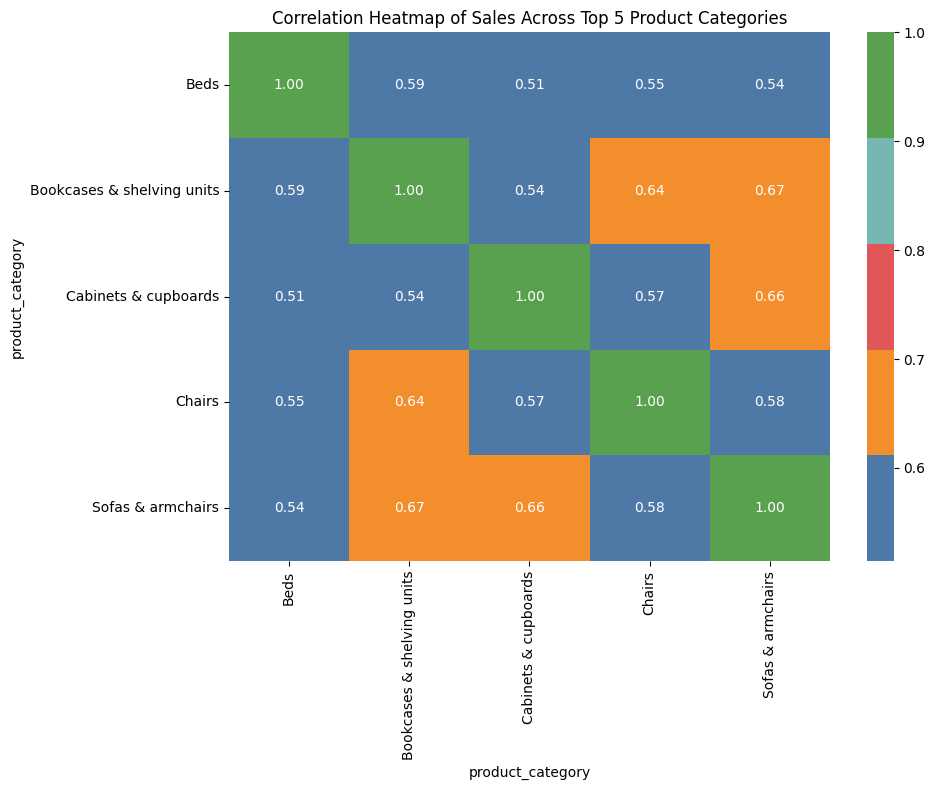

In [204]:
plt.figure(figsize=(10, 8))
sns.heatmap(pivoted_categories_sales.corr(numeric_only=True),
            annot=True,
            cmap=custom_tableau_palette,
            fmt='.2f')
plt.title('Correlation Heatmap of Sales Across Top 5 Product Categories')
plt.tight_layout()
plt.show()

In [205]:
from scipy.stats import pearsonr

product_categories = pivoted_categories_sales.columns
correlation_results_categories = []

for i in range(len(product_categories)):
    for j in range(i + 1, len(product_categories)):
        category1 = product_categories[i]
        category2 = product_categories[j]

        corr, p_value = pearsonr(pivoted_categories_sales[category1], pivoted_categories_sales[category2])
        correlation_results_categories.append({
            'Product Category Pair': f'{category1} vs {category2}',
            'Pearson Correlation': f'{corr:.4f}',
            'P-value': f'{p_value:.4f}',
            'Statistically Significant (p < 0.05)': p_value < 0.05
        })

correlation_df_categories = pd.DataFrame(correlation_results_categories)
print("Correlation and p-values for sales across top 5 product categories:")
display(correlation_df_categories)


Correlation and p-values for sales across top 5 product categories:


,Product Category Pair,Pearson Correlation,P-value,Statistically Significant (p < 0.05)
0,Beds vs Bookcases & shelving units,0.5929,0.0000,True
1,Beds vs Cabinets & cupboards,0.5146,0.0000,True
2,Beds vs Chairs,0.5545,0.0000,True
3,Beds vs Sofas & armchairs,0.5354,0.0000,True
4,Bookcases & shelving units vs Cabinets & cupbo...,0.5394,0.0000,True
5,Bookcases & shelving units vs Chairs,0.6371,0.0000,True
6,Bookcases & shelving units vs Sofas & armchairs,0.6662,0.0000,True
7,Cabinets & cupboards vs Chairs,0.5729,0.0000,True
8,Cabinets & cupboards vs Sofas & armchairs,0.6576,0.0000,True
9,Chairs vs Sofas & armchairs,0.5782,0.0000,True


###### Висновок

**Продажі за п'ятьма провідними категоріями товарів**: П'ять провідних категорій товарів за `total_revenue` — це ліжка, книжкові шафи та стелажі, шафи та комоди, стільці та дивани та крісла. Продажі за всіма парами цих провідних категорій демонструють помірні та сильні позитивні та статистично значущі кореляції, що варіюються від 0.5146 до 0.6662 (усі p-значення: 0.0000). Наприклад, 'Книжкові шафи та стелажі' та 'Дивани та крісла' корелюють на рівні 0.6662. Це свідчить про те, що продажі цих популярних типів товарів часто зростають та падають одночасно.

##### Основні висновки аналізу даних

- Щоденні сесії та продажі: Існує дуже сильна позитивна та статистично значуща кореляція між кількістю щоденних сесій та загальним щоденним обсягом продажів (коефіцієнт кореляції Пірсона: 0.9642, p-значення: 0.0000). Це вказує на те, що більший трафік веб-сайту безпосередньо призводить до збільшення продажів.
- Продажі на трьох провідних континентах: Три провідні континенти за загальним доходом — це Північна та Південна Америка, Азія та Європа. Усі пари цих континентів демонструють сильні позитивні та статистично значущі кореляції у своїх щоденних продажах:
    - Північна та Південна Америка проти Азії: 0.6923 (p-значення: 0.0000)
    - Північна та Південна Америка проти Європи: 0.6695 (p-значення: 0.0000)
    - Азія проти Європи: 0.6678 (p-значення: 0.0000) Це свідчить про те, що тенденції продажів у цих основних регіонах, як правило, рухаються в тандемі.
- Продажі за каналами трафіку: Усі проаналізовані пари каналів трафіку (Direct, Organic Search, Paid Search, Social Search, Undefined) демонструють помірні та сильні позитивні та статистично значущі кореляції у своїх щоденних продажах, що варіюються від 0.3593 до 0.8082 (усі p-значення < 0.0006). Наприклад, 'Organic Search' та 'Paid Search' мають сильну позитивну кореляцію 0.8082. Це означає, що ефективність продажів за різними каналами залучення часто є взаємозалежною.
- Продажі за п'ятьма провідними категоріями товарів: П'ять провідних категорій товарів — це ліжка, книжкові шафи та стелажі, шафи та комоди, стільці та дивани та крісла. Продажі за всіма парами цих провідних категорій демонструють помірні та сильні позитивні та статистично значущі кореляції, що варіюються від 0.5146 до 0.6662 (усі p-значення: 0.0000). Наприклад, 'Книжкові шафи та стелажі' та 'Дивани та крісла' корелюють на рівні 0.6662. Це свідчить про те, що продажі цих популярних типів товарів часто зростають та падають одночасно.

### 8.Статистичний аналіз відмінностей між групами.

1. Проаналізуй продажі за кожну дату зареєстрованих та незареєстрованих користувачів. Створи відповідні вибірки, проаналізуй розподіли даних в обох вибірках. Підбери відповідний статистичний тест для порівняння вибірок. Зроби висновок щодо статистичної значущості отриманих результатів.
2. Проаналізуй кількість сесій за різними каналами трафіку. Підбери відповідний тест. Чи є статистично значущі відмінності між групами?
3. Чи відрізняється статистично доля сесій з органічним трафіком у Європі та Америці? Підбери відповідний тест. Проведи потрібні обчислення для створення вхідних даних до тесту.

	Додай ще декілька відомих тобі статистичних тестів до цього пункту.


##### 8.1. Дані про щоденні продажі для зареєстрованих та незареєстрованих користувачів

Створимо два окремі DataFrames: один для щоденних продажів зареєстрованих користувачів, а інший для щоденних продажів незареєстрованих користувачів. Згрупуємо `df_analysis` за `order_date`  щоб обчислити загальний щоденний обсяг продажів для кожної групи.


In [206]:
# №1 prepare the data for statistical comparison
registered_users_df = df_analysis[df_analysis['registered_user_id'] != 0]
daily_registered_sales_df = registered_users_df.groupby('order_date')['total_revenue'].sum().reset_index()

unregistered_users_df = df_analysis[df_analysis['registered_user_id'] == 0]
daily_unregistered_sales_df = unregistered_users_df.groupby('order_date')['total_revenue'].sum().reset_index()

print("Daily sales for registered users (first 5 rows):")
display(daily_registered_sales_df.head())

print("\nDaily sales for unregistered users (first 5 rows):")
display(daily_unregistered_sales_df.head())

Daily sales for registered users (first 5 rows):


,order_date,total_revenue
0,2020-11-01,21547.0
1,2020-11-02,44956.8
2,2020-11-03,29150.5
3,2020-11-04,20982.2
4,2020-11-05,25334.6



Daily sales for unregistered users (first 5 rows):


,order_date,total_revenue
0,2020-11-01,222745.5
1,2020-11-02,310550.0
2,2020-11-03,469829.1
3,2020-11-04,318204.9
4,2020-11-05,365942.0


###### Візуалізація розподілів:
Побудуємо гістограми розподілу щоденних продажів для обох груп.

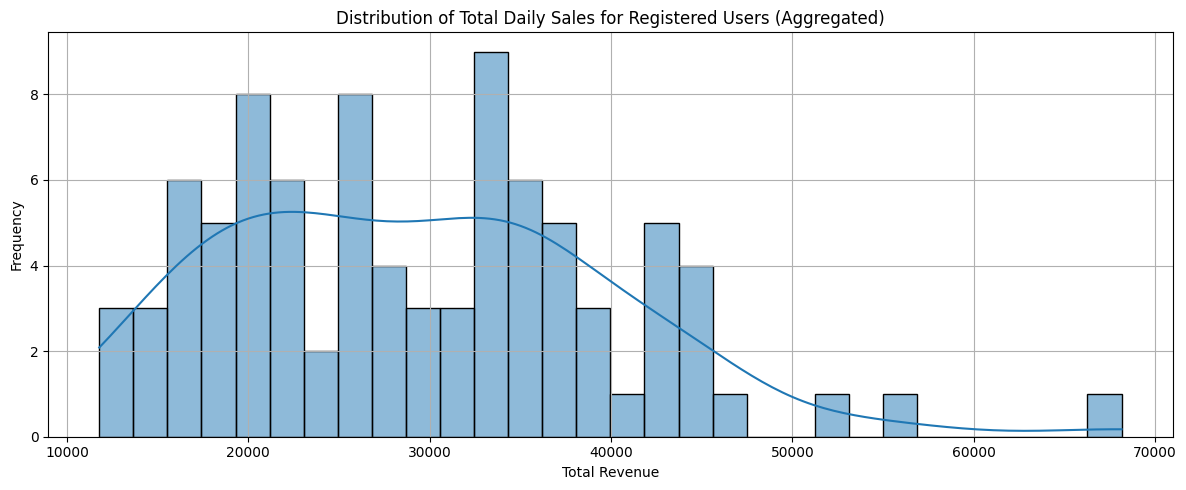

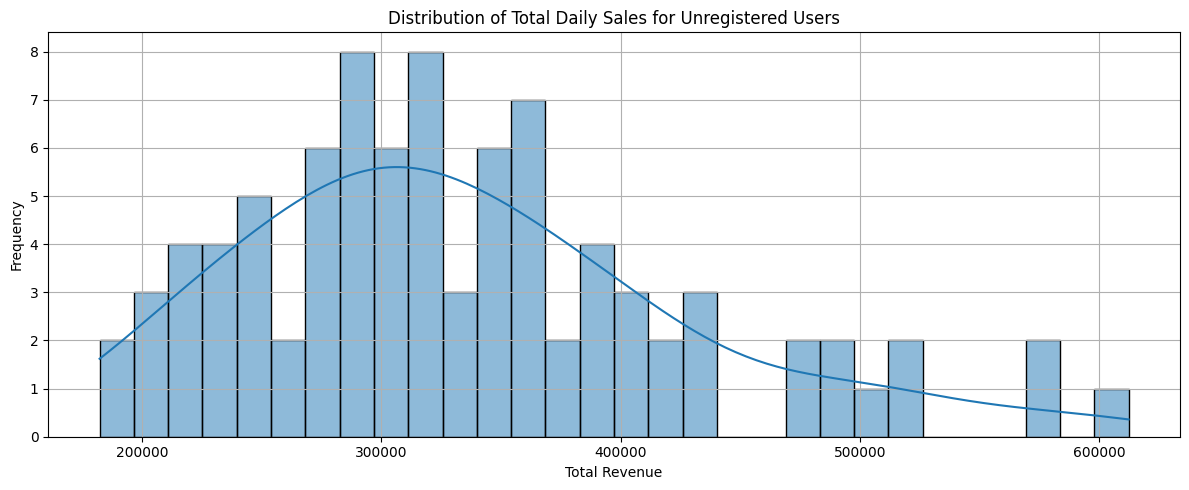

In [207]:
# №2 prepare the data for statistical comparison

plt.figure(figsize=(12, 5))
sns.histplot(daily_registered_sales_df['total_revenue'], kde=True, bins=30)
plt.title('Distribution of Total Daily Sales for Registered Users (Aggregated)')
plt.xlabel('Total Revenue')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(daily_unregistered_sales_df['total_revenue'], kde=True, bins=30)
plt.title('Distribution of Total Daily Sales for Unregistered Users')
plt.xlabel('Total Revenue')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# print("Aggregated daily sales for registered users (first 5 rows):")
# display(daily_registered_sales_df.head())

###### Тест на нормальність (Шапіро-Уілка):

In [208]:
from scipy.stats import shapiro

# Shapiro-Wilk test for daily sales of registered users
stat_registered, p_registered = shapiro(daily_registered_sales_df['total_revenue'])
print(f"Shapiro-Wilk Test for Daily Sales (Registered Users): Statistics={stat_registered:.4f}, p={p_registered:.4f}")

# Shapiro-Wilk test for daily sales of unregistered users
stat_unregistered, p_unregistered = shapiro(daily_unregistered_sales_df['total_revenue'])
print(f"Shapiro-Wilk Test for Daily Sales (Unregistered Users): Statistics={stat_unregistered:.4f}, p={p_unregistered:.4f}")

# Interpret p-values
alpha = 0.05
print("\nNormality Test Results:")
if p_registered > alpha:
    print("\tDaily Sales (Registered Users): Data looks Gaussian (fail to reject H0)")
else:
    print("\tDaily Sales (Registered Users): Data does not look Gaussian (reject H0)")

if p_unregistered > alpha:
    print("\tDaily Sales (Unregistered Users): Data looks Gaussian (fail to reject H0)")
else:
    print("\tDaily Sales (Unregistered Users): Data does not look Gaussian (reject H0)")

Shapiro-Wilk Test for Daily Sales (Registered Users): Statistics=0.9592, p=0.0073
Shapiro-Wilk Test for Daily Sales (Unregistered Users): Statistics=0.9522, p=0.0026

Normality Test Results:
	Daily Sales (Registered Users): Data does not look Gaussian (reject H0)
	Daily Sales (Unregistered Users): Data does not look Gaussian (reject H0)


###### Висновок:
Оскільки обидва розподіли щоденних продажів не є гаусовими (згідно з результатами тесту Шапіро-Уілка), для порівняння двох незалежних вибірок (щоденні продажі зареєстрованих та незареєстрованих користувачів) доречним є непараметричний тест. U-тест Манна-Вітні є придатним непараметричним тестом для цієї мети. Вииконаємо U-тест Манна-Вітні та інтерпретуємо результати, щоб визначити, чи є статистично значущі відмінності між двома групами.

###### Порівняння щоденних продажів для зареєстрованих та незареєстрованих користувачів (U-тест Манна-Вітні)

Виконаємо U-тест Манна-Вітні для порівняння щоденних продажів для зареєстрованих та незареєстрованих користувачів. Цей тест підходить, оскільки обидва розподіли не є нормальними.

In [209]:
from scipy.stats import mannwhitneyu

# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(daily_registered_sales_df['total_revenue'], daily_unregistered_sales_df['total_revenue'], alternative='two-sided')

print(f"Mann-Whitney U Statistic: {stat:.7f}")
print(f"P-value: {p_value:.7f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("\nConclusion:\n\tThere is a statistically significant difference in daily sales between registered and unregistered users (reject H0).")
else:
    print("\nConclusion:\n\tThere is no statistically significant difference in daily sales between registered and unregistered users (fail to reject H0).")

Mann-Whitney U Statistic: 0.0000000
P-value: 0.0000000

Conclusion:
	There is a statistically significant difference in daily sales between registered and unregistered users (reject H0).


###### Висновок

Результати статистичного аналізу щоденних продажів для зареєстрованих та незареєстрованих користувачів такі:

**Тест Манна-Уїтні (Mann-Whitney U test)**: Цей тест виявив статистично значущу різницю в щоденних продажах між зареєстрованими та незареєстрованими користувачами (p-значення = 0.0000). Це означає, що медіана щоденних продажів значно відрізняється між цими двома групами.

**F-тест для дисперсій (F-test for variances)**: F-тест показав статистично значущу різницю в дисперсіях щоденних продажів між зареєстрованими та незареєстрованими користувачами (p-значення = 0.0000).

Таким чином, можна зробити висновок, що як медіанні значення, так і розкид щоденних продажів суттєво відрізняються між зареєстрованими та незареєстрованими користувачами.

##### 8.2. Дані про кількість сеансів за каналами трафіку

Обчислимо загальну кількість сеансів для кожного каналу трафіку, підрахувавши унікальні ідентифікатори сеансів.

In [210]:
sessions_by_channel_df = df_analysis.groupby('traffic_channel')['session_id'].nunique().reset_index()
sessions_by_channel_df.rename(columns={'session_id': 'unique_sessions_count'}, inplace=True)

print("Total number of unique sessions per traffic channel:")
display(sessions_by_channel_df.head())

Total number of unique sessions per traffic channel:


,traffic_channel,unique_sessions_count
0,Direct,7800
1,Organic Search,11921
2,Paid Search,9042
3,Social Search,2716
4,Undefined,2059


###### Візуалізація кількості унікальних сесій за каналами трафіку за допомогою стовпчастої діаграми

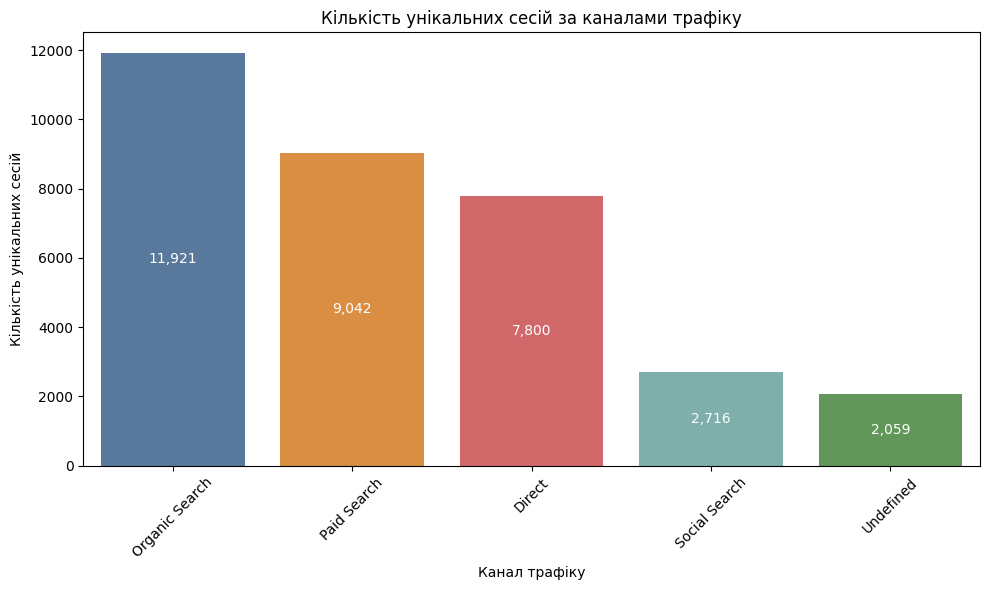

In [211]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
ax = plt.gca()

plot_bar_visualization_grid(
    df=sessions_by_channel_df.sort_values(by='unique_sessions_count', ascending=False),
    x_col='traffic_channel',
    y_col='unique_sessions_count',
    title='Кількість унікальних сесій за каналами трафіку',
    xlabel='Канал трафіку',
    ylabel='Кількість унікальних сесій',
    ax=ax,
    rotation=45,
    inside_bar_value=True,
    custom_palette=custom_tableau_palette
)

plt.tight_layout()
plt.show()

Обчислимо щоденний трафік для кожного каналу.



In [212]:
daily_sessions_by_channel_df = df_analysis.groupby(['order_date', 'traffic_channel'])['session_id'].nunique().reset_index()
daily_sessions_by_channel_df.rename(columns={'session_id': 'daily_unique_sessions_count'}, inplace=True)

print("Daily unique sessions count per traffic channel:")
display(daily_sessions_by_channel_df.head())


Daily unique sessions count per traffic channel:


,order_date,traffic_channel,daily_unique_sessions_count
0,2020-11-01,Direct,72
1,2020-11-01,Organic Search,105
2,2020-11-01,Paid Search,70
3,2020-11-01,Social Search,21
4,2020-11-01,Undefined,13


###### Тест на нормальність (Шапіро-Уілка):

In [213]:
from scipy.stats import shapiro

traffic_channels = daily_sessions_by_channel_df['traffic_channel'].unique()
normality_results = []

for channel in traffic_channels:
    channel_data = daily_sessions_by_channel_df[daily_sessions_by_channel_df['traffic_channel'] == channel]['daily_unique_sessions_count']
    if len(channel_data) > 1:
        stat, p = shapiro(channel_data)
        normality_results.append({
            'Traffic Channel': channel,
            'Shapiro-Wilk Statistic': f'{stat:.4f}',
            'P-value': f'{p:.4f}',
            'Is Normal (p > 0.05)': p > 0.05
        })
    else:
        normality_results.append({
            'Traffic Channel': channel,
            'Shapiro-Wilk Statistic': 'N/A',
            'P-value': 'N/A',
            'Is Normal (p > 0.05)': 'Insufficient data'
        })

normality_df = pd.DataFrame(normality_results)
print("Shapiro-Wilk Normality Test Results for Each Traffic Channel:")
display(normality_df)

Shapiro-Wilk Normality Test Results for Each Traffic Channel:


,Traffic Channel,Shapiro-Wilk Statistic,P-value,Is Normal (p > 0.05)
0,Direct,0.9754,0.0928,True
1,Organic Search,0.9498,0.0019,False
2,Paid Search,0.9540,0.0034,False
3,Social Search,0.9700,0.0388,False
4,Undefined,0.9727,0.0596,True


Оскільки не всі групи каналів трафіку розподілені нормально (згідно з результатами тесту Шапіро-Уілка), доцільним є непараметричний тест. H-тест Краскела-Уолліса є придатним непараметричним тестом для порівняння кількох незалежних вибірок. Виконаємо цей тест, щоб визначити, чи є статистично значущі відмінності в кількості сеансів між каналами трафіку.

In [214]:
from scipy.stats import kruskal

traffic_channels = daily_sessions_by_channel_df['traffic_channel'].unique()

# Prepare data for Kruskal-Wallis test
channel_data_list = []
for channel in traffic_channels:
    channel_data_list.append(daily_sessions_by_channel_df[daily_sessions_by_channel_df['traffic_channel'] == channel]['daily_unique_sessions_count'].values)

# Perform Kruskal-Wallis H-test
h_statistic, p_value = kruskal(*channel_data_list)

print(f"Kruskal-Wallis H-Statistic: {h_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Conclusion:\n\tThere is a statistically significant difference in the number of sessions across traffic channels (reject H0).")
else:
    print("Conclusion:\n\tThere is no statistically significant difference in the number of sessions across traffic channels (fail to reject H0).")

Kruskal-Wallis H-Statistic: 349.4251
P-value: 0.0000
Conclusion:
	There is a statistically significant difference in the number of sessions across traffic channels (reject H0).


###### Аналіз частки органічного трафіку (Європа проти Америки)

Відфільтруємо df_analysis для трафіку «Органічний пошук», а потім обчислимо загальну кількість органічних сеансів та загальну кількість сеансів для «Європи» та «Америки».


In [215]:
import pandas as pd

# 1. Filter df_analysis for 'Organic Search' traffic
organic_traffic_df = df_analysis[df_analysis['traffic_channel'] == 'Organic Search']

# 2. Filter organic_traffic_df to include only sessions from 'Europe' or 'Americas' continents
organic_continent_df = organic_traffic_df[organic_traffic_df['continent'].isin(['Europe', 'Americas'])]

# 3. Group organic_continent_df by 'continent' and count unique session_ids for organic sessions
organic_sessions_per_continent = organic_continent_df.groupby('continent')['session_id'].nunique().reset_index()
organic_sessions_per_continent.rename(columns={'session_id': 'organic_sessions'}, inplace=True)

# 4. Filter the original df_analysis DataFrame to include only sessions from 'Europe' or 'Americas' continents
total_continent_df = df_analysis[df_analysis['continent'].isin(['Europe', 'Americas'])]

# 5. Group total_continent_df by 'continent' and count unique session_ids for total sessions
total_sessions_per_continent = total_continent_df.groupby('continent')['session_id'].nunique().reset_index()
total_sessions_per_continent.rename(columns={'session_id': 'total_sessions'}, inplace=True)

# 6. Display the DataFrames
print("Organic Sessions per Continent (Europe vs. Americas):")
display(organic_sessions_per_continent)

print("\nTotal Sessions per Continent (Europe vs. Americas):")
display(total_sessions_per_continent)


Organic Sessions per Continent (Europe vs. Americas):


,continent,organic_sessions
0,Americas,6536
1,Europe,2238



Total Sessions per Continent (Europe vs. Americas):


,continent,total_sessions
0,Americas,18553
1,Europe,6261


##### 8.3. Порівняємо частку сеансів органічного трафіку між Європою та Америкою,
для чого об'єднаємо кількість органічних та загальних сеансів для кожного континенту та розрахуємо частку органічного трафіку для кожного. Це підготує дані для відповідного статистичного тесту -  `хі-квадрат` тест або `Z-тест` для визначення пропорцій.



In [216]:
import pandas as pd

# Merge the organic_sessions_per_continent and total_sessions_per_continent DataFrames
continent_proportions_df = pd.merge(organic_sessions_per_continent,
                                    total_sessions_per_continent,
                                    on='continent', how='inner')

# Calculate the proportion of organic sessions for each continent
continent_proportions_df['organic_proportion'] = continent_proportions_df['organic_sessions'] / continent_proportions_df['total_sessions']

print("Proportion of Organic Sessions per Continent (Europe vs. Americas):")
display(continent_proportions_df)


Proportion of Organic Sessions per Continent (Europe vs. Americas):


,continent,organic_sessions,total_sessions,organic_proportion
0,Americas,6536,18553,0.352288
1,Europe,2238,6261,0.357451


Для порівняння частки сеансів органічного трафіку між Європою та Америкою потрібен відповідний статистичний тест. Оскільки дані складаються з підрахунку (органічних сеансів та загальної кількості сеансів для кожного континенту), для визначення наявності статистично значущої різниці підходить `Chi-squared test` тест для визначення частки


In [217]:
from scipy.stats import chi2_contingency

# Prepare the contingency table for the Chi-squared test
# Rows: Continents (Americas, Europe)
# Columns: Organic Sessions, Non-Organic Sessions

# Calculate non-organic sessions for each continent
continent_proportions_df['non_organic_sessions'] = continent_proportions_df['total_sessions'] - continent_proportions_df['organic_sessions']

contingency_table = continent_proportions_df[['organic_sessions', 'non_organic_sessions']].values

# Perform the Chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("\nConclusion:\n\tThere is a statistically significant difference in the proportion of organic traffic sessions between Europe and Americas (reject H0).")
else:
    print("\nConclusion:\n\tThere is no statistically significant difference in the proportion of organic traffic sessions between Europe and Americas (fail to reject H0).")


Chi-squared Statistic: 0.5236
P-value: 0.4693

Conclusion:
	There is no statistically significant difference in the proportion of organic traffic sessions between Europe and Americas (fail to reject H0).


###### Порівняння дисперсій щоденних продажів для зареєстрованих та незареєстрованих користувачів (F-тест для дисперсій)

Виконаємо F-тест для порівняння дисперсій щоденних продажів для зареєстрованих та незареєстрованих користувачів.


In [218]:
from scipy.stats import f
import numpy as np

# 1. Extract the 'total_revenue' series for daily sales of registered users
registered_sales = daily_registered_sales_df['total_revenue']

# Extract the 'total_revenue' series for daily sales of unregistered users
unregistered_sales = daily_unregistered_sales_df['total_revenue']

# 2. Calculate the variance of each of these series
var_registered = np.var(registered_sales, ddof=1)  # ddof=1 for sample variance
var_unregistered = np.var(unregistered_sales, ddof=1)

print(f"Variance for Registered Users' Daily Sales: {var_registered:.2f}")
print(f"Variance for Unregistered Users' Daily Sales: {var_unregistered:.2f}")

# 3. Compute the F-statistic by dividing the larger variance by the smaller variance
if var_registered >= var_unregistered:
    f_statistic = var_registered / var_unregistered
    df1 = len(registered_sales) - 1
    df2 = len(unregistered_sales) - 1
else:
    f_statistic = var_unregistered / var_registered
    df1 = len(unregistered_sales) - 1
    df2 = len(registered_sales) - 1

# 4. Determine the degrees of freedom for each sample (number of observations - 1)
# df1 and df2 are already set in the previous step

# 5. Calculate the p-value using the scipy.stats.f.cdf function
# For a two-tailed test, we calculate cdf(F) and multiply by 2,
# or if F > 1, use 2 * (1 - cdf(F)) for the upper tail.
# In this case, f_statistic is always >= 1, so we use 2 * (1 - cdf(F)).
p_value = 2 * (1 - f.cdf(f_statistic, df1, df2))

# If using a one-tailed test, it would be f.cdf(f_statistic, df1, df2) or 1 - f.cdf(f_statistic, df1, df2)

print(f"\nF-statistic: {f_statistic:.4f}")
print(f"Degrees of Freedom (df1, df2): ({df1}, {df2})")
print(f"P-value: {p_value:.4f}")

# 6. Print a conclusion about the statistical significance
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion:\n\tWith a p-value of {p_value:.4f} (which is less than alpha={alpha}), we reject the null hypothesis.")
    print("\tThere is a statistically significant difference in the variances of daily sales between registered and unregistered users.")
else:
    print(f"\nConclusion:\n\tWith a p-value of {p_value:.4f} (which is greater than or equal to alpha={alpha}), we fail to reject the null hypothesis.")
    print("\tThere is no statistically significant difference in the variances of daily sales between registered and unregistered users.")

Variance for Registered Users' Daily Sales: 115894949.28
Variance for Unregistered Users' Daily Sales: 8632306577.37

F-statistic: 74.4839
Degrees of Freedom (df1, df2): (87, 87)
P-value: 0.0000

Conclusion:
	With a p-value of 0.0000 (which is less than alpha=0.05), we reject the null hypothesis.
	There is a statistically significant difference in the variances of daily sales between registered and unregistered users.


###### Порівняння кількості сеансів у кількох групах `traffic_channel` (H-тест Краскела-Уолліса)

Застосуємо H-тест Краскела-Уолліса для порівняння кількості сеансів у кількох групах `traffic_channel`. Цей тест підходить, якщо дані не відповідають припущенням ANOVA (наприклад, нормальності).


In [219]:
from scipy.stats import kruskal

traffic_channels = daily_sessions_by_channel_df['traffic_channel'].unique()

# Prepare data for Kruskal-Wallis test
channel_data_list = []
for channel in traffic_channels:
    channel_data_list.append(daily_sessions_by_channel_df[daily_sessions_by_channel_df['traffic_channel'] == channel]['daily_unique_sessions_count'].values)

# Perform Kruskal-Wallis H-test
h_statistic, p_value = kruskal(*channel_data_list)

print(f"Kruskal-Wallis H-Statistic: {h_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Conclusion:\n\tThere is a statistically significant difference in the number of sessions across traffic channels (reject H0).")
else:
    print("Conclusion:\n\tThere is no statistically significant difference in the number of sessions across traffic channels (fail to reject H0).")

Kruskal-Wallis H-Statistic: 349.4251
P-value: 0.0000
Conclusion:
	There is a statistically significant difference in the number of sessions across traffic channels (reject H0).


###### Висновки

**Ключові результати аналізу даних**

**Щоденні продажі (зареєстровані та незареєстровані користувачі)**: U-тест Манна-Вітні (p-значення = 0,0000) виявив статистично значущу різницю в щоденних продажах між зареєстрованими та незареєстрованими користувачами. Крім того, F-тест (p-значення = 0,0000) вказав на статистично значущу різницю в дисперсіях щоденних продажів між цими двома групами, причому незареєстровані користувачі показали набагато більшу дисперсію ($8,632,306,577.37) порівняно з зареєстрованими користувачами ($115,894,949.28).

**Кількість сеансів за різними каналами трафіку**:
H-тест Краскела-Уолліса (p-значення = 0,0000) показав статистично значущу різницю в кількості сеансів за різними каналами трафіку. Це вказує на те, що середня кількість унікальних сеансів за день не однакова для всіх каналів трафіку.
Тест Шапіро-Уілка на нормальність показав, що кількість щоденних сеансів для каналів «Прямий» та «Невизначений» розподілялася нормально, тоді як для каналів «Органічний пошук», «Платний пошук» та «Соціальний пошук» розподілявся ненормально.
Початкова кількість сеансів на канал становила: Прямий (7800), Органічний пошук (11921), Платний пошук (9042), Соціальний пошук (2716) та Невизначений (2059).

**Питання органічного трафіку (Європа проти Америки)**: Хі-квадрат тест (p-значення = 0,4693) показав, що немає статистично значущої різниці в частці сеансів органічного трафіку між Європою та Америкою. Частка органічних сеансів становила приблизно 0,3523 для Америки (6536 органічних сеансів із 18553 загальних сеансів) та 0,3575 для Європи (2238 органічних сеансів із 6261 загальних сеансів).

**Аналітика або наступні кроки
Дослідження розбіжностей у щоденних продажах**:

Враховуючи значну різницю як у щоденних продажах, так і в їх відхиленнях між зареєстрованими та незареєстрованими користувачами, необхідний подальший аналіз, щоб зрозуміти чинники, що стоять за цими відмінностями. Це може включати дослідження поведінки покупців, середньої вартості замовлення та показників залученості користувачів, специфічних для кожної групи.
Оптимізація ефективності каналів трафіку: Статистично значущі відмінності в кількості сеансів між каналами трафіку свідчать про можливість оптимізації маркетингових стратегій. Глибше занурення в показники ефективності (наприклад, коефіцієнти конверсії, дохід за сеанс) кожного каналу є виправданим для ефективнішого розподілу ресурсів та потенційного виявлення каналів з низькою або високою ефективністю.

### Створимо аналітичний дашборд у Tableau Public.

In [220]:
# Create SQL for Tableau
query_tableau = """
SELECT
    s.date,
    sp.country,
    sp.device,
    p.category,
    p.name AS product,
    SUM(p.price) AS revenue,
    COUNT(o.ga_session_id) AS order_cnt
FROM `DA.order` o
JOIN `DA.session` s ON o.ga_session_id = s.ga_session_id
JOIN `DA.product` p ON o.item_id = p.item_id
JOIN `DA.session_params` sp ON o.ga_session_id = sp.ga_session_id
group by
    s.date,
    sp.country,
    sp.device,
    p.category,
    p.name
"""

df_sales_v1 = client.query(query_tableau).result().to_dataframe()
print(f"Table sales: {df_sales_v1.size}")
print(f"Table first_5:\n{df_sales_v1.head()}")
print(f"Table info:\n{df_sales_v1.info()}")


Table sales: 213199
Table first_5:
         date        country   device              category  product  revenue  \
0  2020-11-06       Slovakia   mobile  Children's furniture  TROFAST      5.0   
1  2020-11-10  United States  desktop  Children's furniture  TROFAST    590.0   
2  2020-11-24  United States  desktop  Children's furniture  TROFAST    995.0   
3  2020-11-26  United States  desktop  Children's furniture  TROFAST    425.0   
4  2020-12-03          Spain  desktop  Children's furniture  TROFAST      5.0   

   order_cnt  
0          1  
1          5  
2          4  
3          3  
4          1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30457 entries, 0 to 30456
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       30457 non-null  dbdate 
 1   country    30457 non-null  object 
 2   device     30457 non-null  object 
 3   category   30457 non-null  object 
 4   product    30457 non-null  object 


In [221]:
from google.colab import drive


### Під'єднаємось до джерела даних

In [222]:
# Make connection & mapping Google Drive ащк local usу
drive.mount("/content/drive")
%pwd
# %ls
%cd /content/drive/MyDrive/MA/Portfolio_Project_1
%pwd
# %cd ../
%ls -AlsF


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/MA/Portfolio_Project_1
total 4190
   1 -rw------- 1 root root     174 Jan 21 08:43 'Copy of Portfolio Project 1.gdoc'
 373 -rw------- 1 root root  381704 Feb  4 14:42  Portfolio_project_Data_Overview.ipynb
1916 -rw------- 1 root root 1961438 Feb 23 15:33  Portfolio_Project_project.ipynb
1897 -rw------- 1 root root 1941705 Feb 23 15:14  sales_v1.csv
   4 drwx------ 2 root root    4096 Jan 21 09:57  wrk/


In [223]:
df_sales_v1.to_csv('sales_v1.csv', index=False)
print("DataFrame `df_sales_v1` збережено у файл `Sales_v1.csv`")

DataFrame `df_sales_v1` збережено у файл `Sales_v1.csv`


#### Посилання на візуалізацію продажів: [аналітичний дашборд у Tableau Public](https://public.tableau.com/views/Sales_v2_17659838986550/Sales?:language=en-US&:sid=&:display_count=n&:origin=viz_share_link)